In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
# from quiescence_analysis.src.quiescence_analysis import load_tiff, get_average_ref_area, get_frame_diff, get_crop_positions_from_mat, filter_with_zscore

from quiescence_analysis.src.quiescence_analysis import get_frame_diff, get_crop_positions_from_mat, filter_with_zscore

%load_ext autoreload
%autoreload 2

### load binarized image ###

In [7]:
# img_path = r'C:\Temp\quiescence\quiescence_analysis\bin_worm_example.tiff'
# img_path = r'C:\Temp\quiescence\quiescence_analysis\quiesence_analysis\dev\cropped_worm44_binarized.tiff'

img_path = r'C:\Temp\quiescence\quiescence_analysis\quiescence_analysis\dev\cropped_worm29_binarized.tiff'

In [4]:
#load other worm data
import scipy.io
import re

wormID_re = re.findall('(?<=worm)\d+', img_path)
if wormID_re:
    wormID = int(wormID_re[0])
    print("worm ID is",wormID)
else:
    print("couldnt find worm ID")
        
matfile_path = r'C:\Temp\quiescence\quiescence_analysis\quiescence_analysis\dev\2021-12-21_13-49-52_A112_2xhis_1per_R1_MMStack_ome_v2_tracks_JR_als.mat'

mat = scipy.io.loadmat(matfile_path)
centroid = get_crop_positions_from_mat(mat,wormID)
# centroid = np.vstack((mat["Tracks"]["Path"][0,wormID][:,0],mat["Tracks"]["Path"][0,wormID][:,1])).T

worm ID is 29


### investigate contours ###

-----------------future versus past----------------------


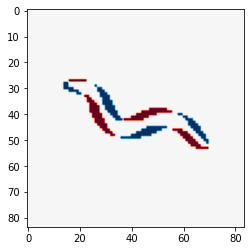

-----------------segment detection ----------------------


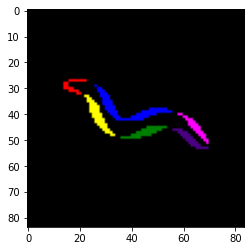

In [16]:
from skimage.measure import label, regionprops
from skimage.color import label2rgb
from quiescence_analysis.src.quiescence_analysis import load_tiff

img = load_tiff(img_path)
frame_shift = 5
idx = 1200

frame = img[idx]
next_frame = img[idx+frame_shift]
print("-----------------future versus past----------------------")
plt.imshow(next_frame-frame,cmap='RdBu')
plt.show()
print("-----------------segment detection ----------------------")
frames_diff = np.abs(next_frame-frame).astype(np.uint8)
# contours, hierarchy = cv2.findContours(frames_diff, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
label_frames_diff = label(frames_diff)
segments = regionprops(label_frames_diff)
image_label_overlay = label2rgb(label_frames_diff)
plt.imshow(image_label_overlay)

### Analysis of different frame shifts ###

In [4]:
#run the frame diff for different frame shifts
frame_shifts = list(range(1,30,10))
results_list = list()

for frame_shift in frame_shifts:
    frame_diff = get_frame_diff(img_path,frame_shift=frame_shift,norm_size_threshold=1,centroid=centroid,debug=False)
    frame_diff = filter_with_zscore(frame_diff,3)
    results_list.append(frame_diff)


Text(0.5, 0, 'time(frames)')

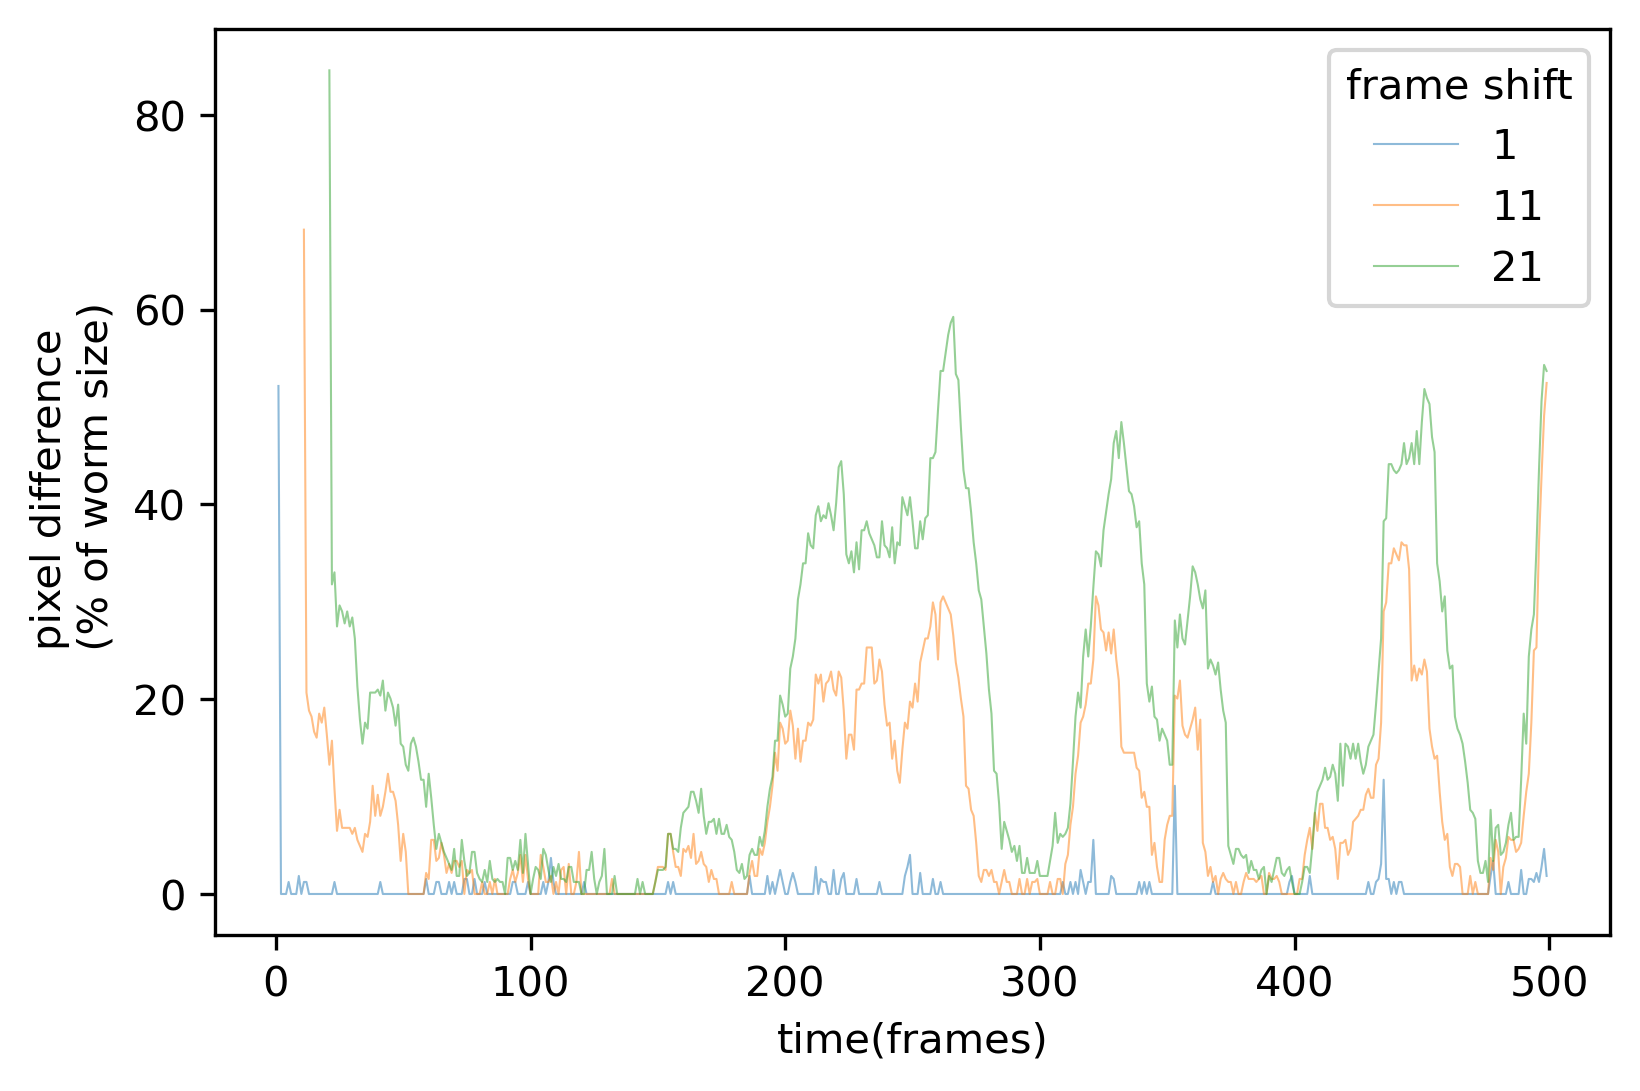

In [5]:
#make the figure
fig,ax = plt.subplots(dpi=300)
for result in results_list:
    ax.plot(result[0:500],linewidth=0.5,alpha=0.5)

plt.legend(frame_shifts,title='frame shift')
ax.set_ylabel('pixel difference \n (% of worm size)')
ax.set_xlabel('time(frames)')

### compare speed vs. pixel diff ###

In [8]:
import pandas as pd

speed_df = pd.DataFrame(mat["Tracks"]["Speed"][0,wormID].T,columns = ['Speed'])

In [9]:
frame_diff = get_frame_diff(img_path,frame_shift=5,norm_size_threshold=1,centroid=centroid,debug=False)


In [10]:
len(frame_diff)

1518

In [7]:
speed_df.index

RangeIndex(start=0, stop=3297, step=1)

Text(0.5, 0, 'time(frames)')

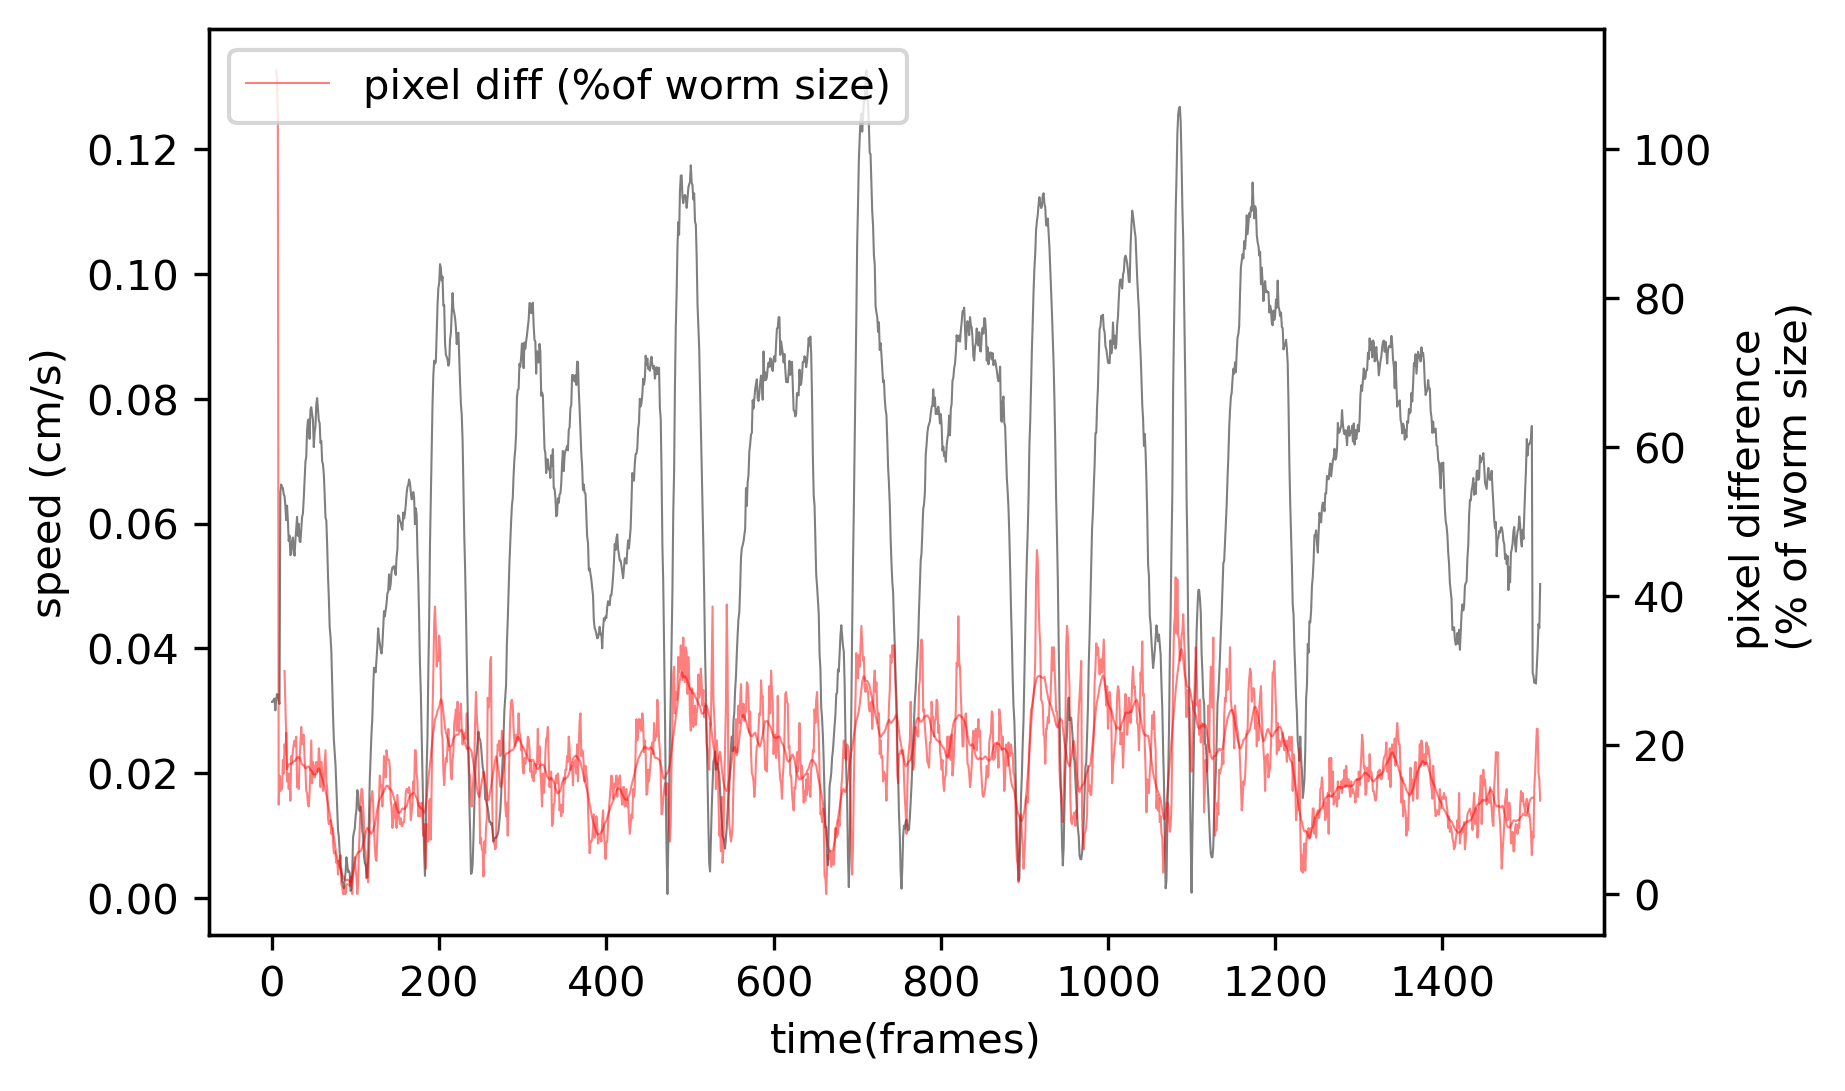

In [11]:
# frame_diff = get_frame_diff(img_path,frame_shift=8,norm_size_threshold=1,centroid=centroid,debug=False)
from scipy import stats
frame_diff[np.abs(stats.zscore(frame_diff) > 3)] = np.nan

# frame_diff_fixed_crop = get_frame_diff_fixed_crop(img_path,frame_shift=5,norm_size_threshold=1,ind=44,debug=False)

frame_diff_df = pd.DataFrame(frame_diff,columns=['pixel_diff'])
# frame_diff_fixed_crop_df = pd.DataFrame(results_arr_bin,columns=['pixel_diff_fixed_crop'])
fig,ax = plt.subplots(dpi=300)
ax.plot(speed_df,color='k',alpha=0.5,linewidth=0.5)
# ax.plot(frame_diff_df.rolling(window=20,center=True).mean(),color='b',alpha=0.5,linewidth=0.5)
ax2 = ax.twinx()
ax2.plot(frame_diff,color='r',alpha=0.5,linewidth=0.5)
ax2.plot(frame_diff_df.rolling(window=20,center=True).mean(),color='r',alpha=0.5,linewidth=0.5)
# ax2.plot(frame_diff_fixed_crop_df.rolling(window=20,center=True).mean(),color='m',alpha=0.5,linewidth=0.5)
plt.legend(['pixel diff (%of worm size)'],loc=2)

ax.set_ylabel('speed (cm/s)')
ax2.set_ylabel('pixel difference \n (% of worm size)')
ax.set_xlabel('time(frames)')


In [49]:
frame_diff

(3291,)

In [59]:
frame_diff[np.abs(stats.zscore(frame_diff) < 3)]


array([59.55988699,  6.78920992,  5.24620766, ..., 14.50422118,
       14.19562073, 14.81282163])

<AxesSubplot:>

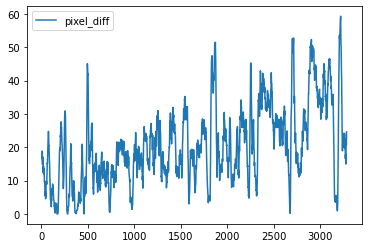

In [37]:
from scipy import stats
frame_diff_df = frame_diff_df[(np.abs(stats.zscore(frame_diff_df)) < 3).all(axis=1)]

frame_diff_df.rolling(window=15,center=True).mean().plot()

### threshold for noise in frame diff ###

In [23]:
from quiescence_analysis.src.quiescence_analysis import get_segment_area_stats
if 'img' not in locals():
    img = load_tiff(img_path)

In [24]:
stats_area = get_segment_area_stats(img,frame_shift=5)
worm_size = get_average_ref_area(img_path,0.1,debug=False)

In [25]:
# set threshold
size_threshold = 1

### fixing gitter ###

In [3]:
avi_path = r'C:\Temp\quiescence\quiescence_analysis\quiesence_analysis\dev\cropped_worm44.avi'


In [4]:
centroid_path = r'C:\Temp\quiescence\quiescence_analysis\quiesence_analysis\dev\centroid_worms.h5'

In [44]:
mat["Tracks"]["Path"][0,44][0:10,1]


In [59]:
n = 20
print(centroid[n])
print(mat["Tracks"]["Path"][0,5][n,0],mat["Tracks"]["Path"][0,5][n,1])

[1261.72619048 1678.28571429]
1261.7261904761904 1678.2857142857142


In [34]:
mat['Tracks']['SmoothY'][0,ind][0:10]

array([[1671.80084643, 1671.81215555, 1671.83167191, ..., 1764.40697799,
        1764.46975098, 1764.54152923]])

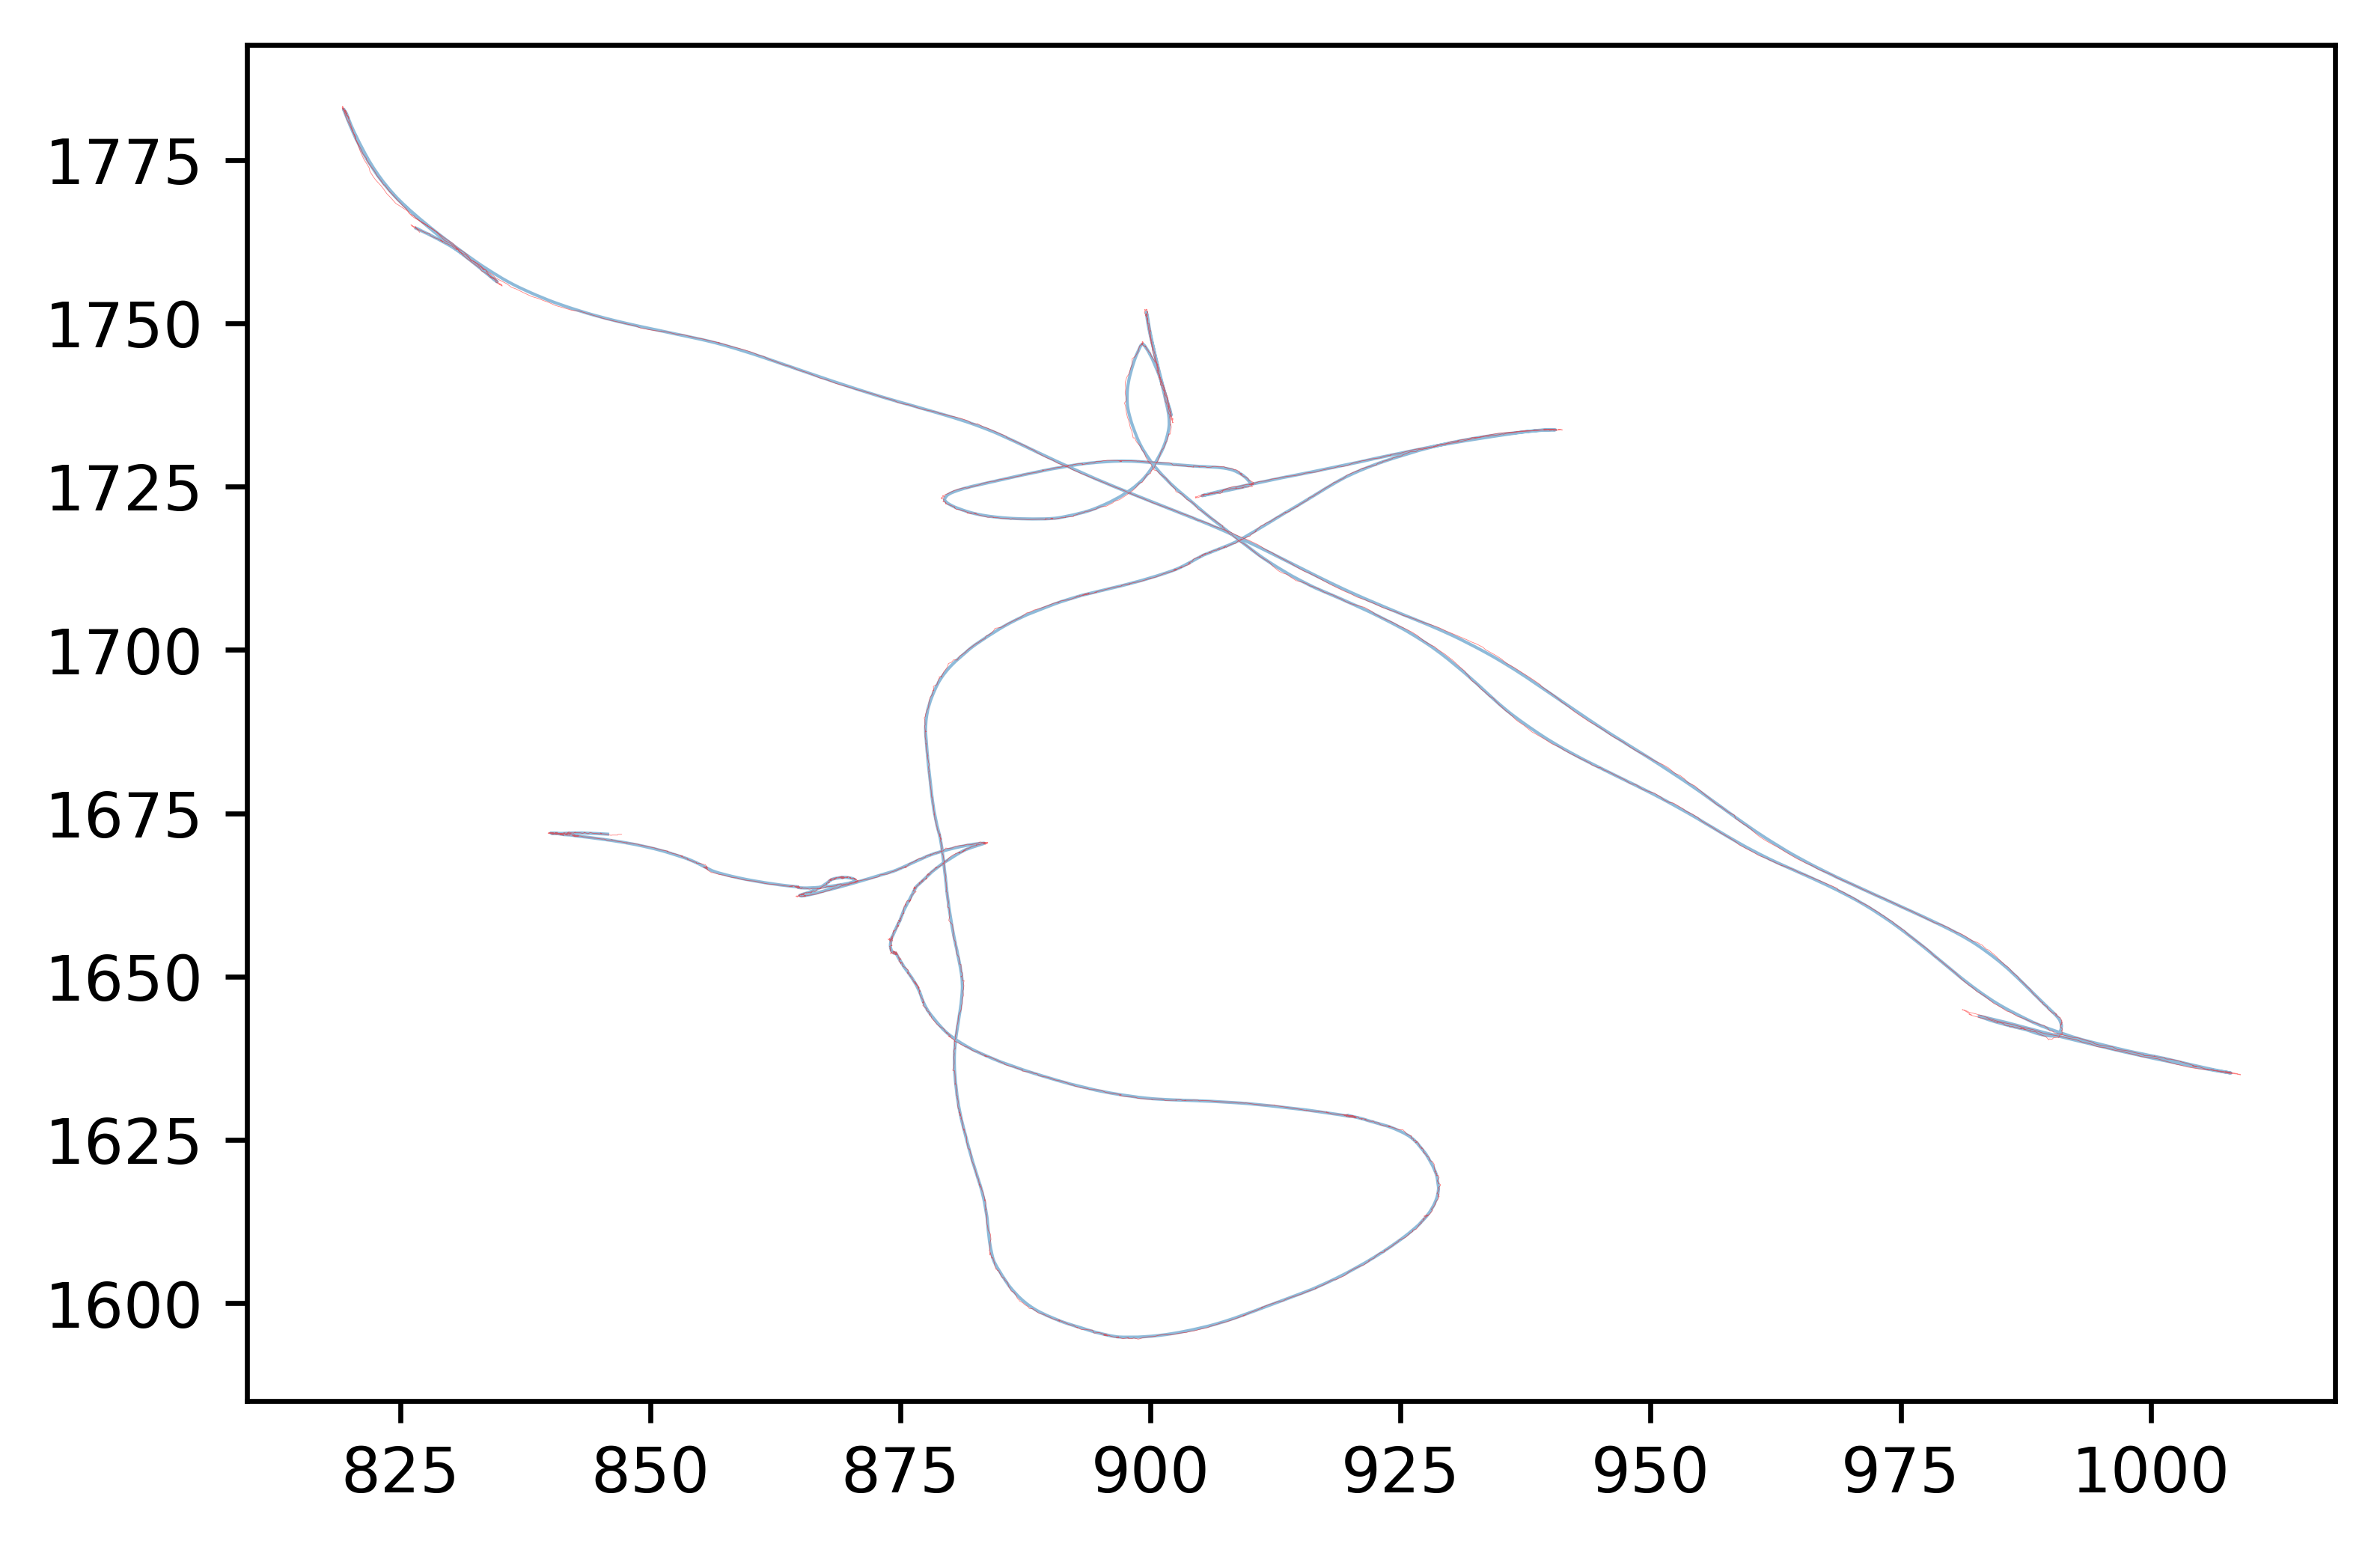

In [43]:
plt.figure(dpi=600)
ind = 44

plt.plot(mat['Tracks']['SmoothX'][0,ind][0],mat['Tracks']['SmoothY'][0,ind][0],linewidth=0.5,alpha=0.5)
plt.plot(mat["Tracks"]["Path"][0,44][:,0],mat["Tracks"]["Path"][0,44][:,1],linewidth=0.1,color='r',alpha=0.5)

In [3]:
x = 1


In [4]:
if x:
    print("hi")

hi


In [219]:
def get_fixed_crop_based_on_centroid(frame,next_frame,centroid,next_centroid,debug:bool=False):
    
    #organize x,y diff
    shape_frame = frame.shape
    max_x = shape_frame[1]
    max_y = shape_frame[0]
    
    x = int(centroid[0])
    y = int(centroid[1])
    x2 = int(next_centroid[0])
    y2 = int(next_centroid[1])
    
    diff_x = x2-x
    diff_y = y2-y
    
    if debug:print("original diff_x",diff_x,"diff_y",diff_y)
        
    
    if debug:print("diff_x",diff_x,"diff_y",diff_y)
    if diff_x==0 and diff_y==0:
        return next_frame
    
    #initialize ranges
    x_range_src = (0,max_x)
    y_range_src = (0,max_y)
    x_range_dst = (0,max_x)
    y_range_dst = (0,max_y)
    
    #calculate ranges based on sign of diff
    if diff_x>0:
        x_range_src = (0,max_x-diff_x)
        x_range_dst = (diff_x,max_x)
        if debug: print("x range src",x_range_src,"x range dst",x_range_dst)
    if diff_x<0:
        x_range_src = (0-diff_x,max_x)
        x_range_dst = (0,max_x+diff_x)
        if debug: print("x range src",x_range_src,"x range dst",x_range_dst)
    if diff_y>0:
        y_range_src = (0,max_y-diff_y)
        y_range_dst = (diff_y,max_y)
    if diff_y<0:
        y_range_src = (0-diff_y,max_y)
        y_range_dst = (0,max_y+diff_y)
    
    fixed_next_frame = np.zeros_like(frame)
    fixed_next_frame[y_range_dst[0]:y_range_dst[1],x_range_dst[0]:x_range_dst[1]] = next_frame[y_range_src[0]:y_range_src[1],x_range_src[0]:x_range_src[1]]

    return fixed_next_frame

In [208]:
centroid = (mat["Tracks"]["Path"][0,ind][frame_idx,0],mat["Tracks"]["Path"][0,ind][frame_idx,1])

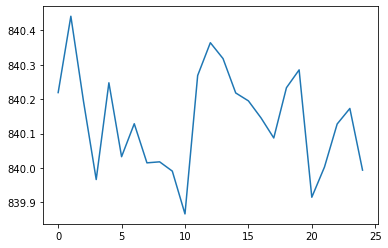

In [217]:
plt.plot(mat["Tracks"]["Path"][0,ind][50:75,0])

In [236]:
img_path = r'C:\Temp\quiescence\quiescence_analysis\quiesence_analysis\dev\cropped_worm44_binarized.tiff'
bin_img = load_tiff(img_path)
img = avi
ind=44
total_frames = mat["Tracks"]["Path"][0,ind].shape[0]
frame_shift = 5
output_path = 'test_all_but_masked_align.tiff'
kernel = np.ones((9, 9), 'uint8')

results_arr_bin = np.zeros(total_frames)

with tiff.TiffWriter(output_path, bigtiff=False) as tif_writer:
    for frame_idx in range(0,total_frames-frame_shift):
#         if frame_idx<60 or frame_idx>80:
#             continue
        
        next_frame_idx = frame_idx+frame_shift
        
        centroid = (mat["Tracks"]["Path"][0,ind][frame_idx,0],mat["Tracks"]["Path"][0,ind][frame_idx,1])
        next_centroid = (mat["Tracks"]["Path"][0,ind][frame_idx+frame_shift,0],mat["Tracks"]["Path"][0,ind][frame_idx+frame_shift,1])
        
        frame = img[frame_idx]
        bin_frame = bin_img[frame_idx]
        dilated_bin_frame  = cv2.dilate(bin_frame,kernel,iterations=2)
        frame_masked = cv2.bitwise_and(frame,dilated_bin_frame)

        next_frame_raw = img[next_frame_idx]
        next_frame_fixed = get_fixed_crop_based_on_centroid(frame,next_frame_raw,centroid,next_centroid,debug=False)
        next_frame_bin_raw = bin_img[next_frame_idx]
        next_frame_bin_fixed = get_fixed_crop_based_on_centroid(bin_frame,next_frame_bin_raw,centroid,next_centroid,debug=False)
        dilated_next_frame_bin_fixed = cv2.dilate(next_frame_bin_fixed,kernel,iterations=2)
        next_frame_masked = cv2.bitwise_and(next_frame_fixed,dilated_next_frame_bin_fixed)
        
#         plt.figure(dpi=300)
        result_frame = bin_frame-next_frame_bin_fixed
#         eroded_dilated_bin_frame = cv2.erode(dilated_bin_frame,kernel,iterations=1)
        mask_for_diff = cv2.bitwise_and(frame_masked,next_frame_masked)
#         print(eroded_dilated_bin_frame.shape)
#         print(result_frame.shape)
        masked_output_frame = cv2.bitwise_or(result_frame,result_frame,mask=mask_for_diff.astype(np.uint8))
#         plt.imshow(masked_output_frame,cmap='PiYG')
        
#         print("------------------frame",frame_idx,"----------------")
#         print("------------------original--------------------------")
#         plt.imshow(frame,alpha=0.5,cmap='Blues')
#         plt.imshow(original_next_frame,alpha=0.5,cmap='Reds')
#         plt.show()
#         #################################################################
#         print("------------------corrected-------------------------")
#         plt.imshow(frame,alpha=0.5,cmap='Blues')
#         plt.imshow(next_frame_fixed,alpha=0.5,cmap='Reds')
#         plt.show()
#         #################################################################
#         print("------------------substucted-------------------------")
#         diff_frames = frame-next_frame_fixed
#         plt.imshow(diff_frames,alpha=0.5,cmap='Greys')
#         plt.show()
#         print("total diff",diff_frames.sum())
#         results_arr_bin[frame_idx] = np.abs(result_frame).sum()
#         results_arr_bin[frame_idx] =  calculate_pixel_diff(bin_frame,next_frame_bin_fixed,360,norm_size_threshold=1)
        
#         hello = input("hello")
        tif_writer.save(masked_output_frame)



### investigating optical flow ###

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


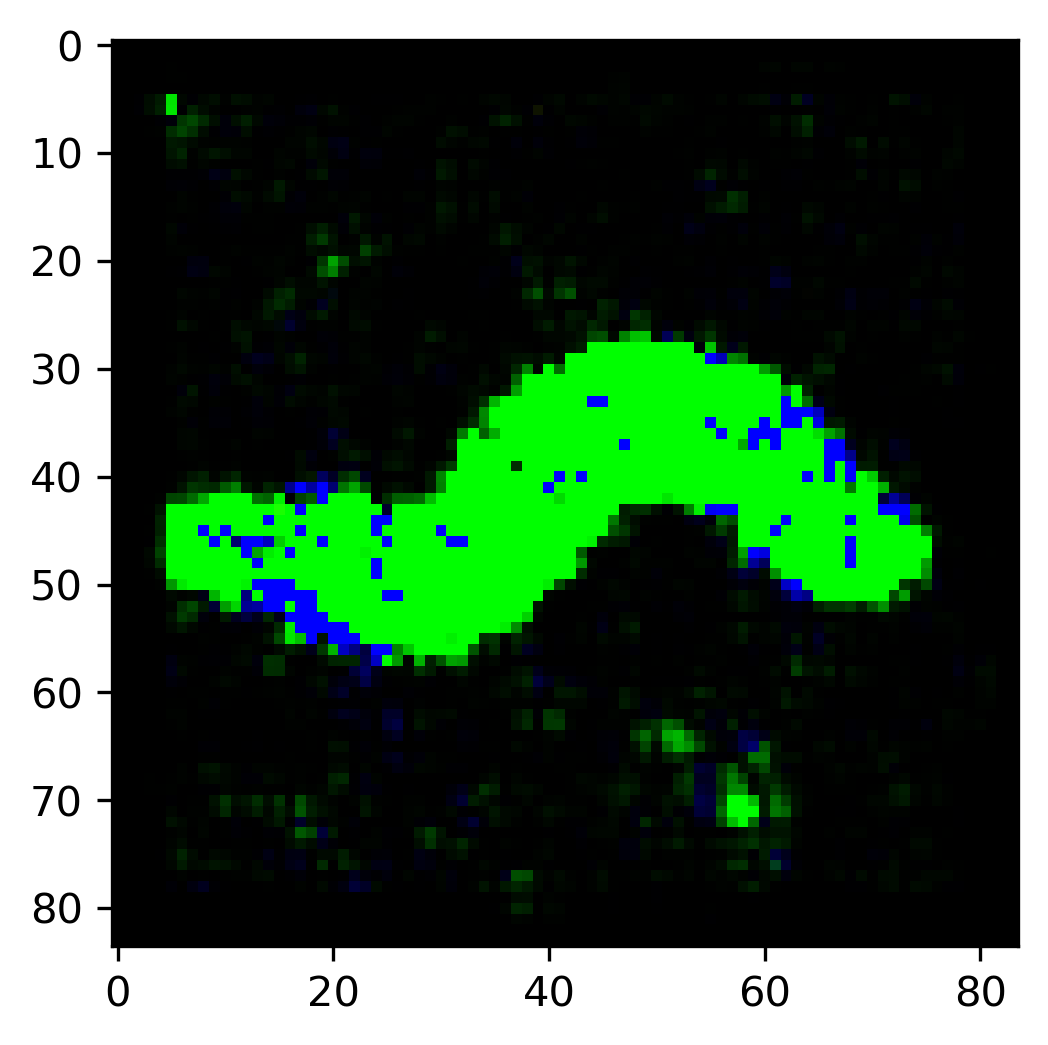

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


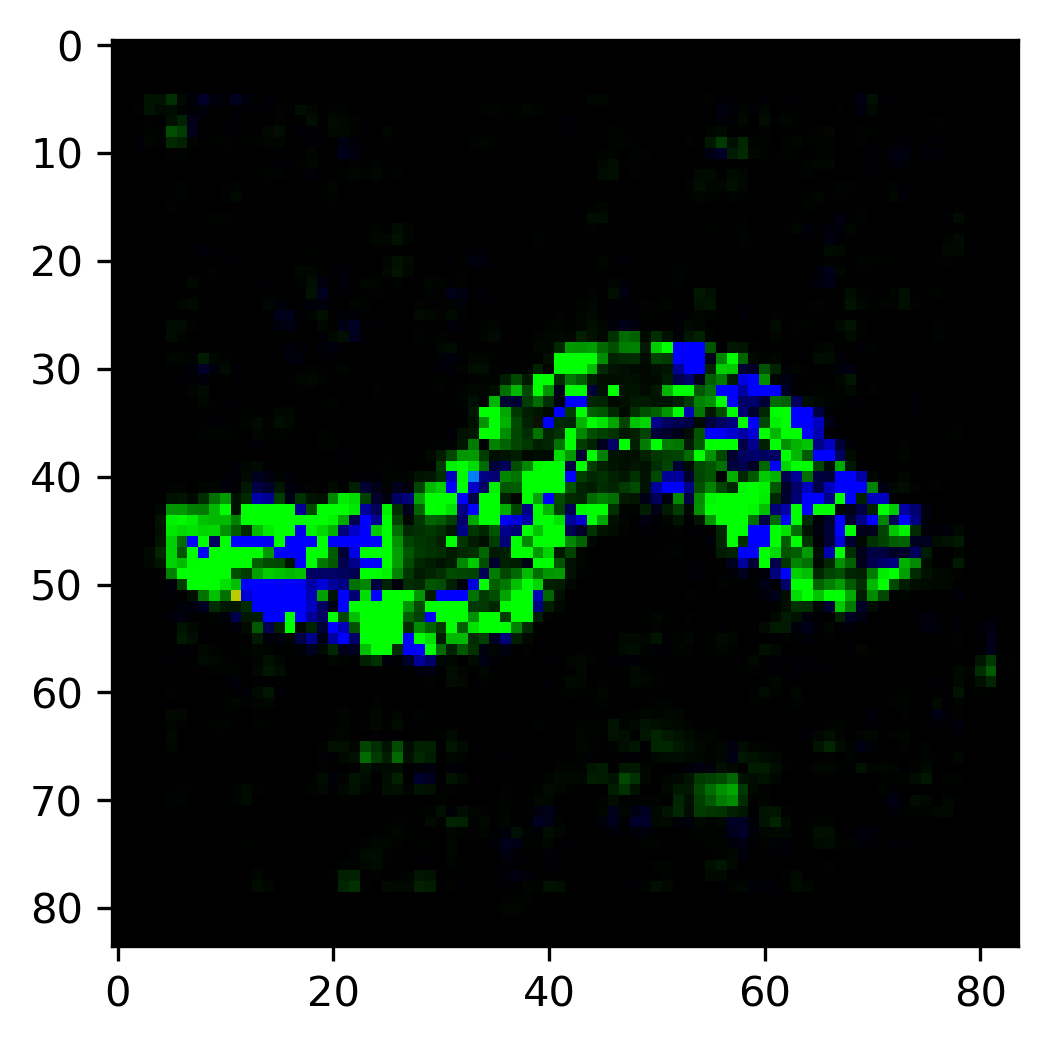

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


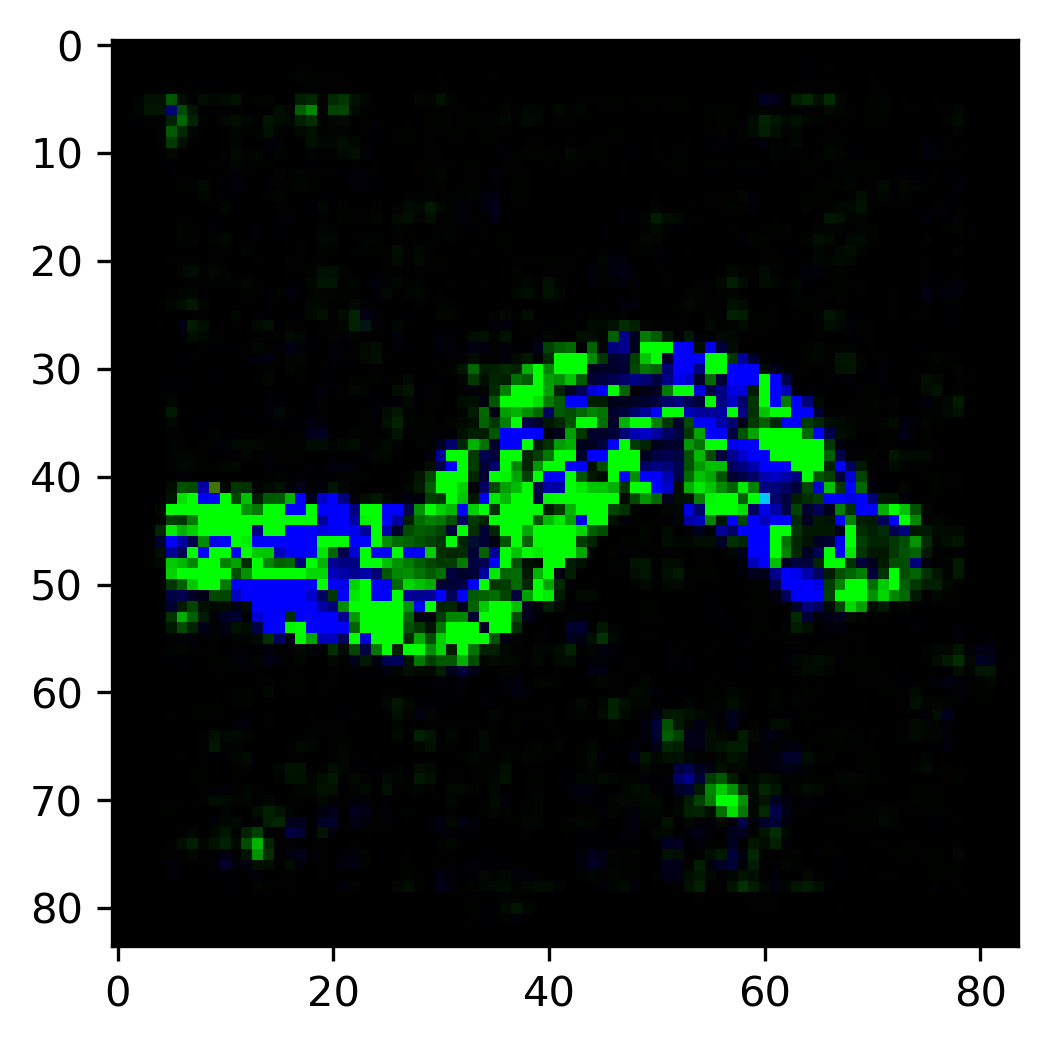

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


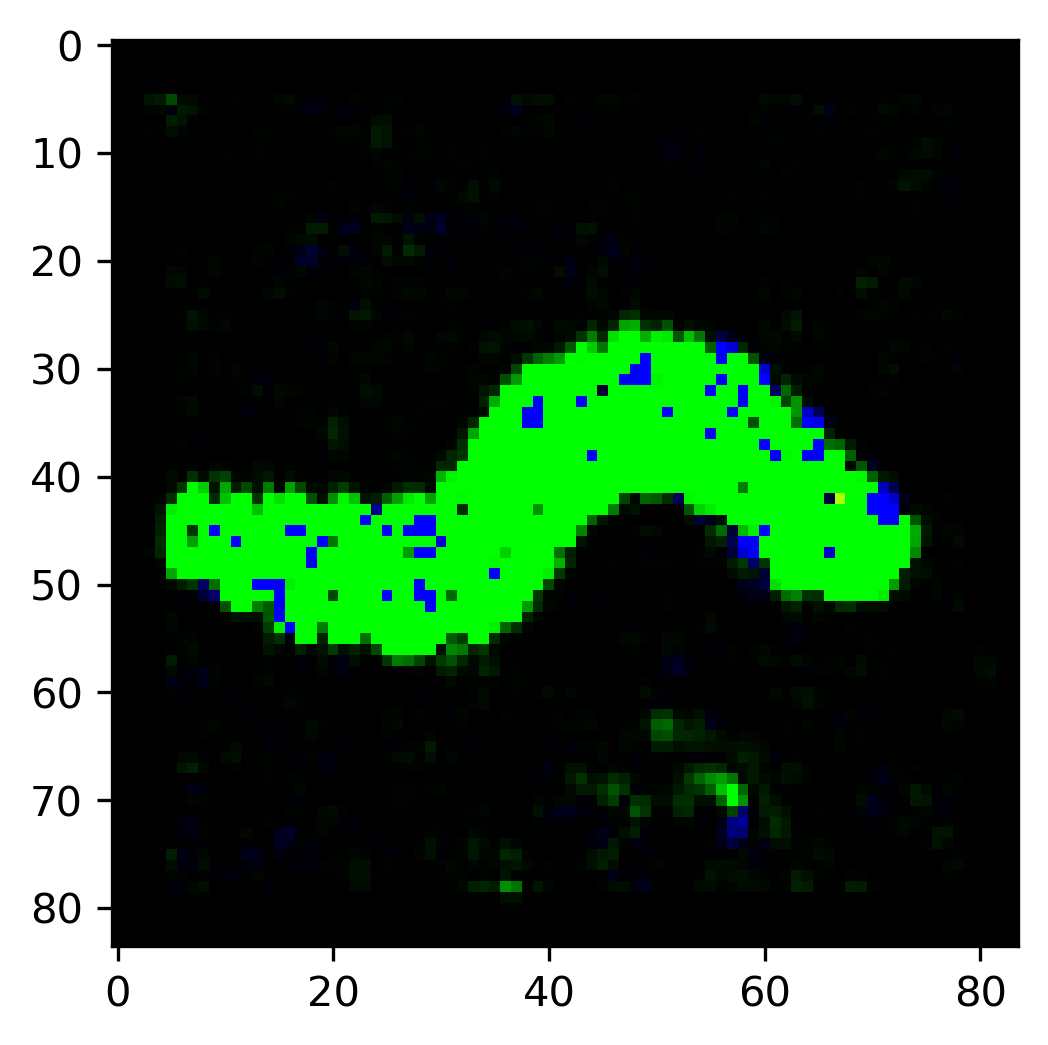

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


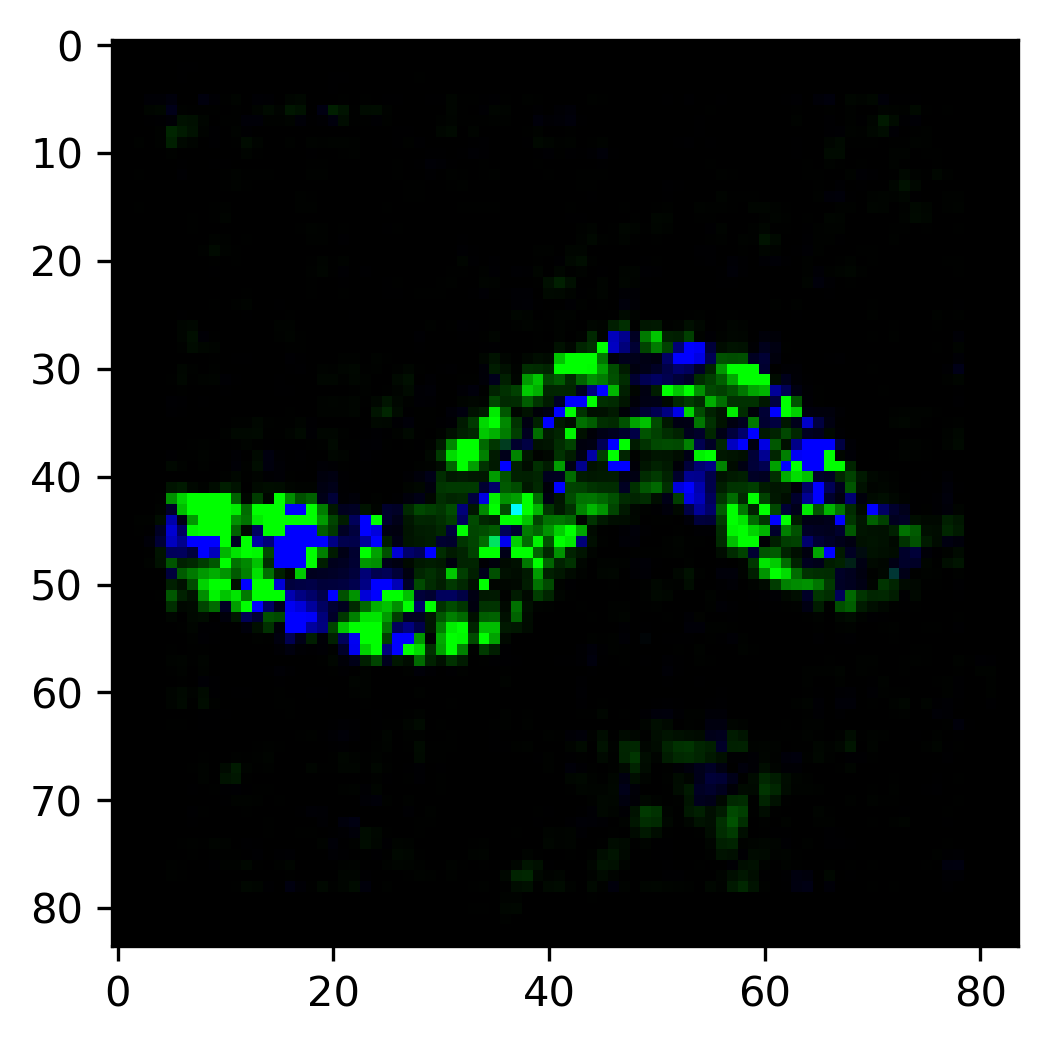

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


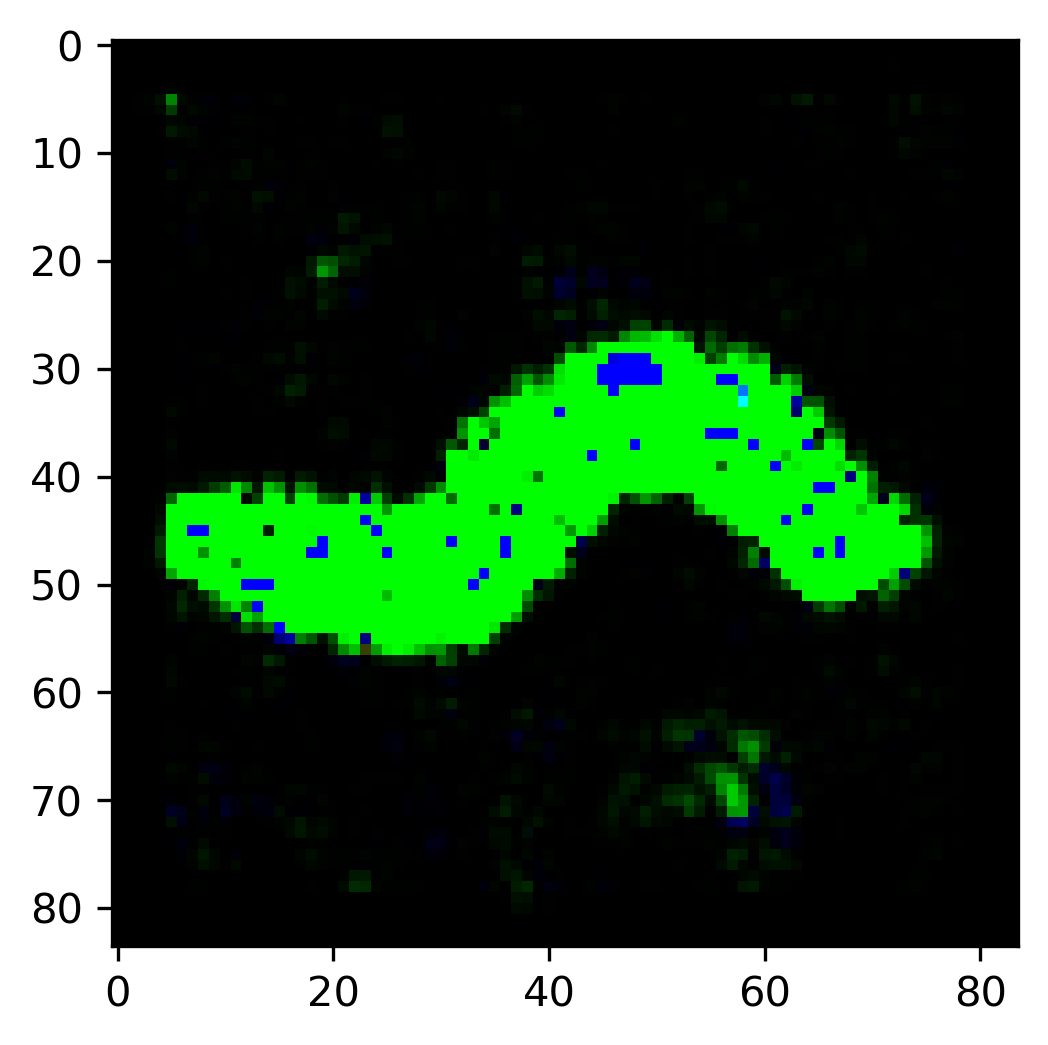

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


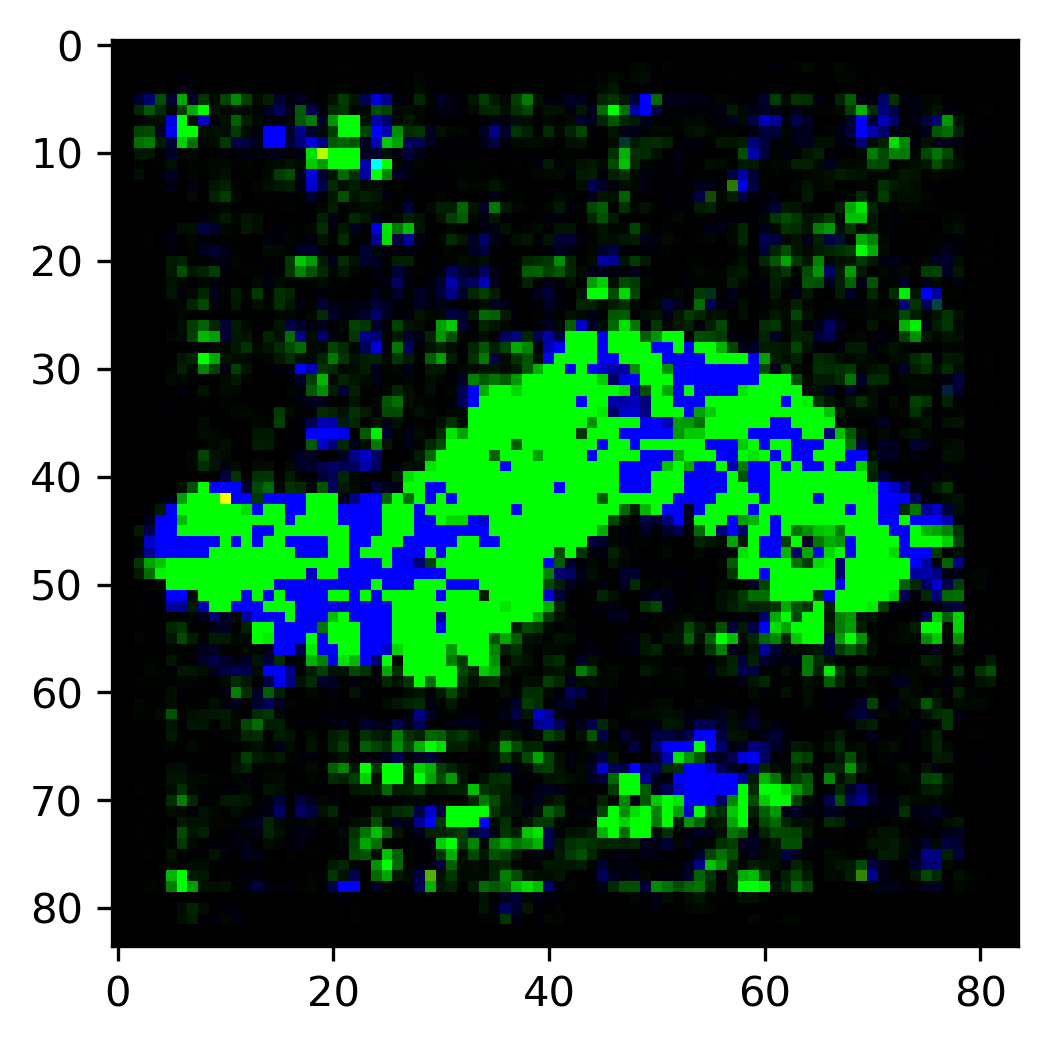

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


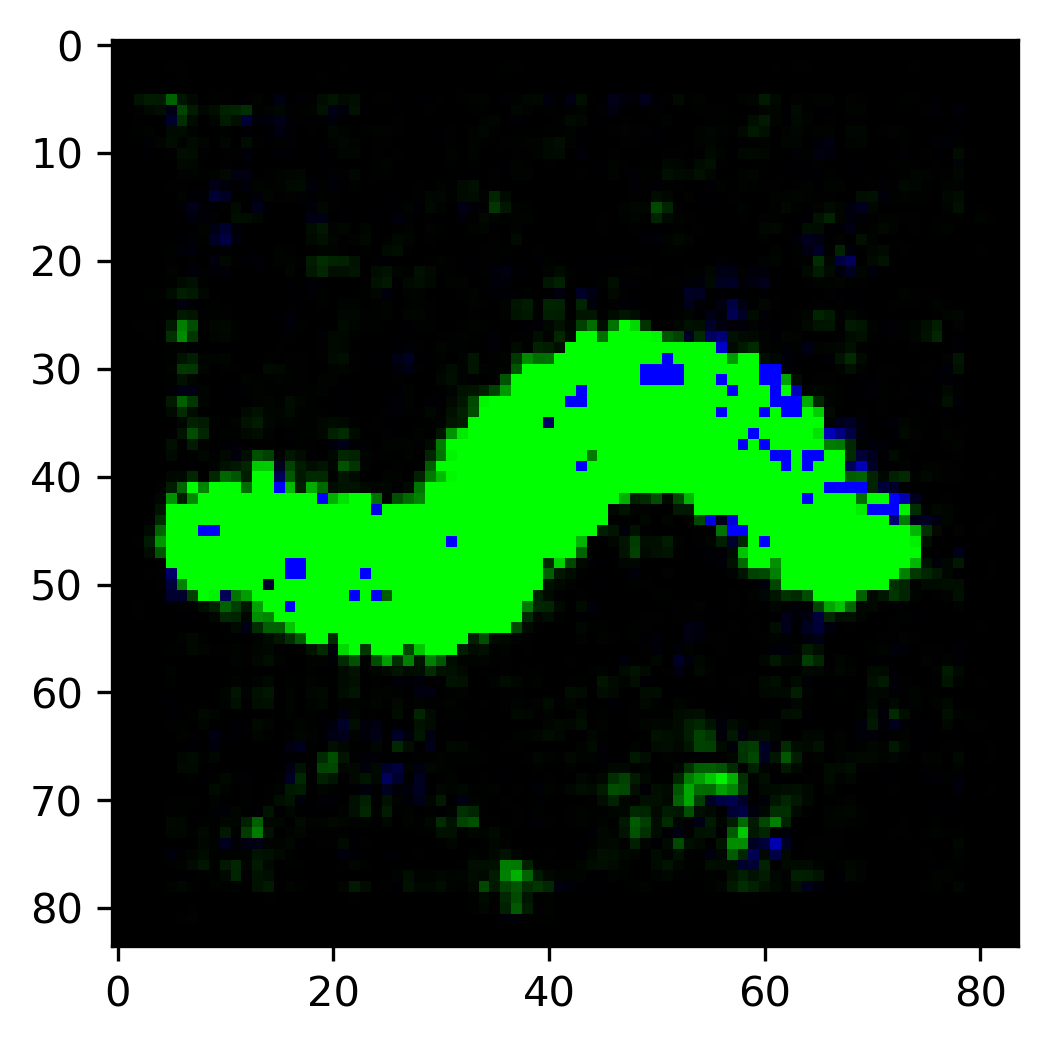

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


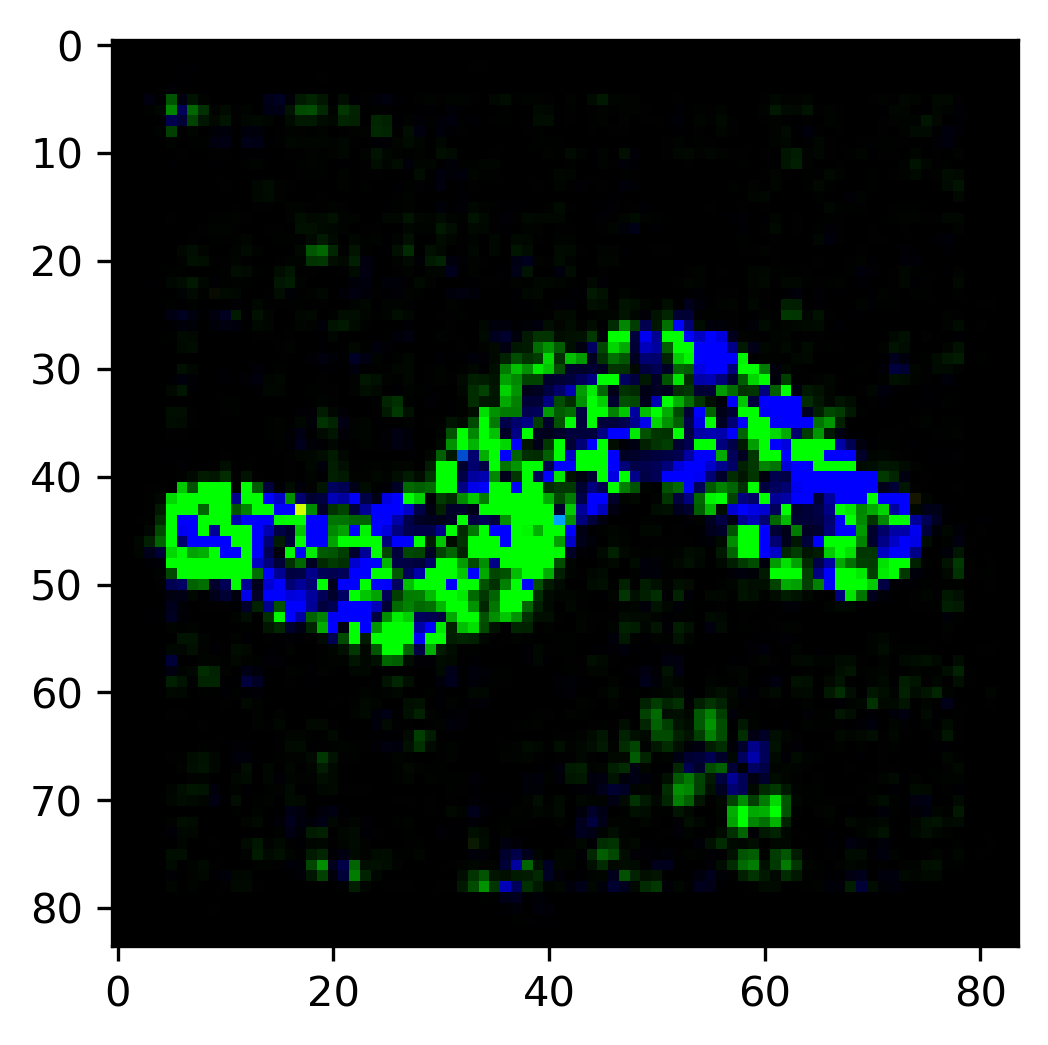

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


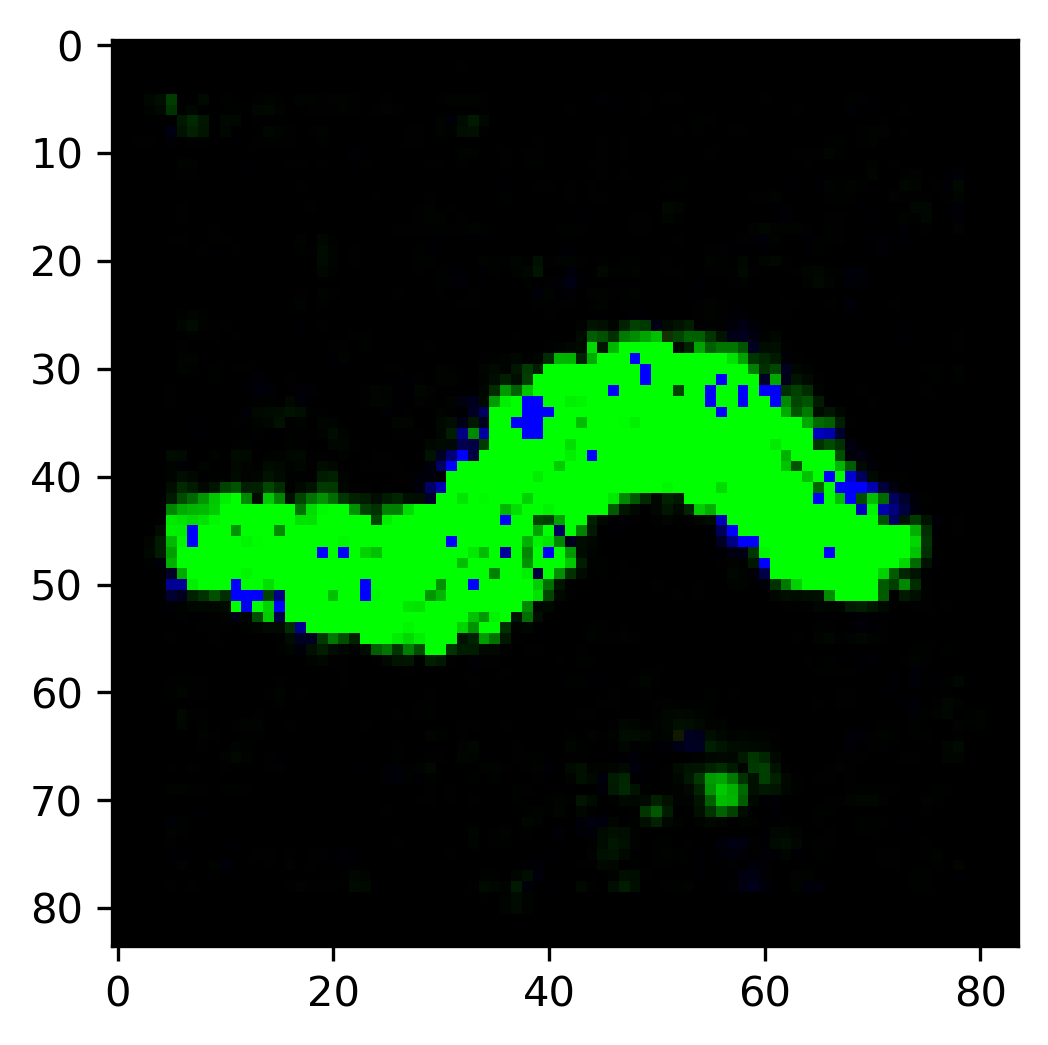

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


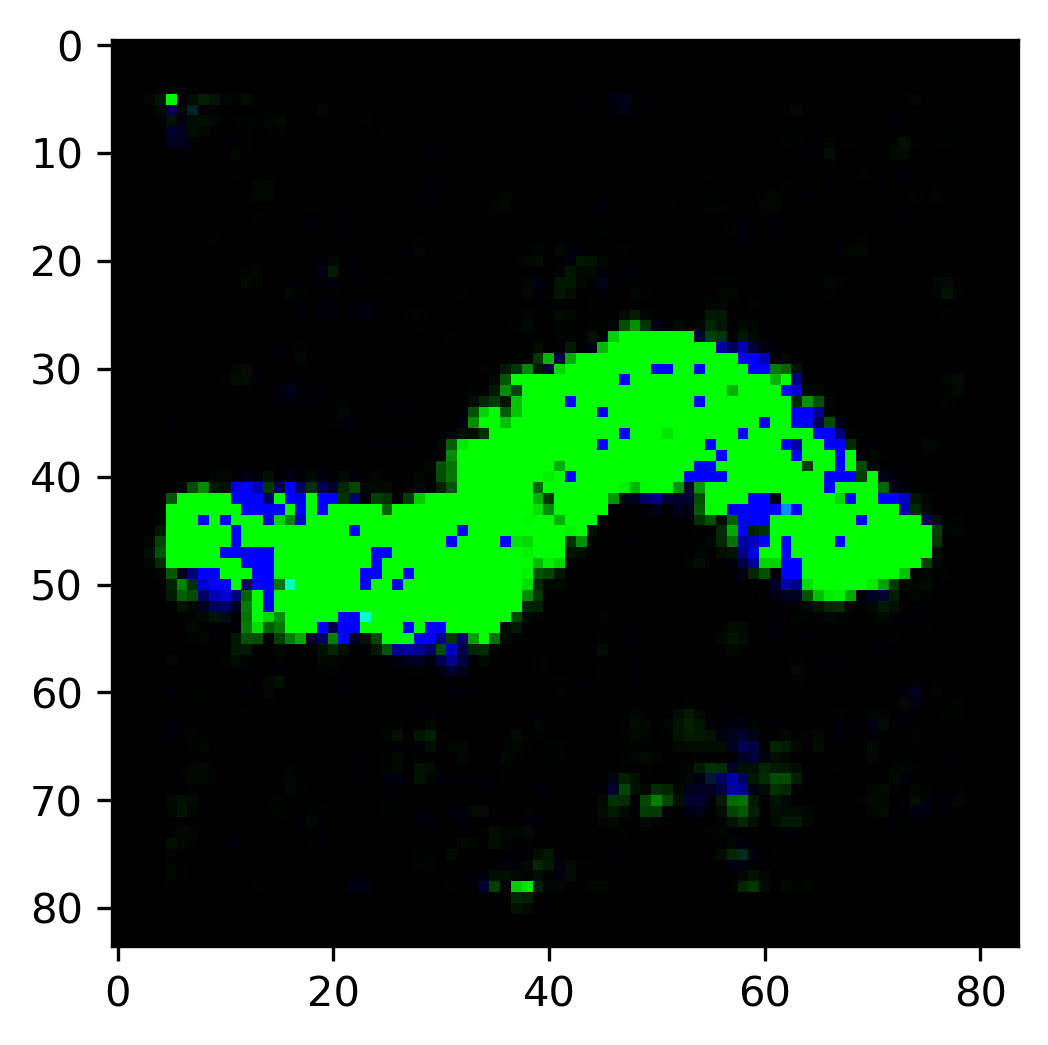

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


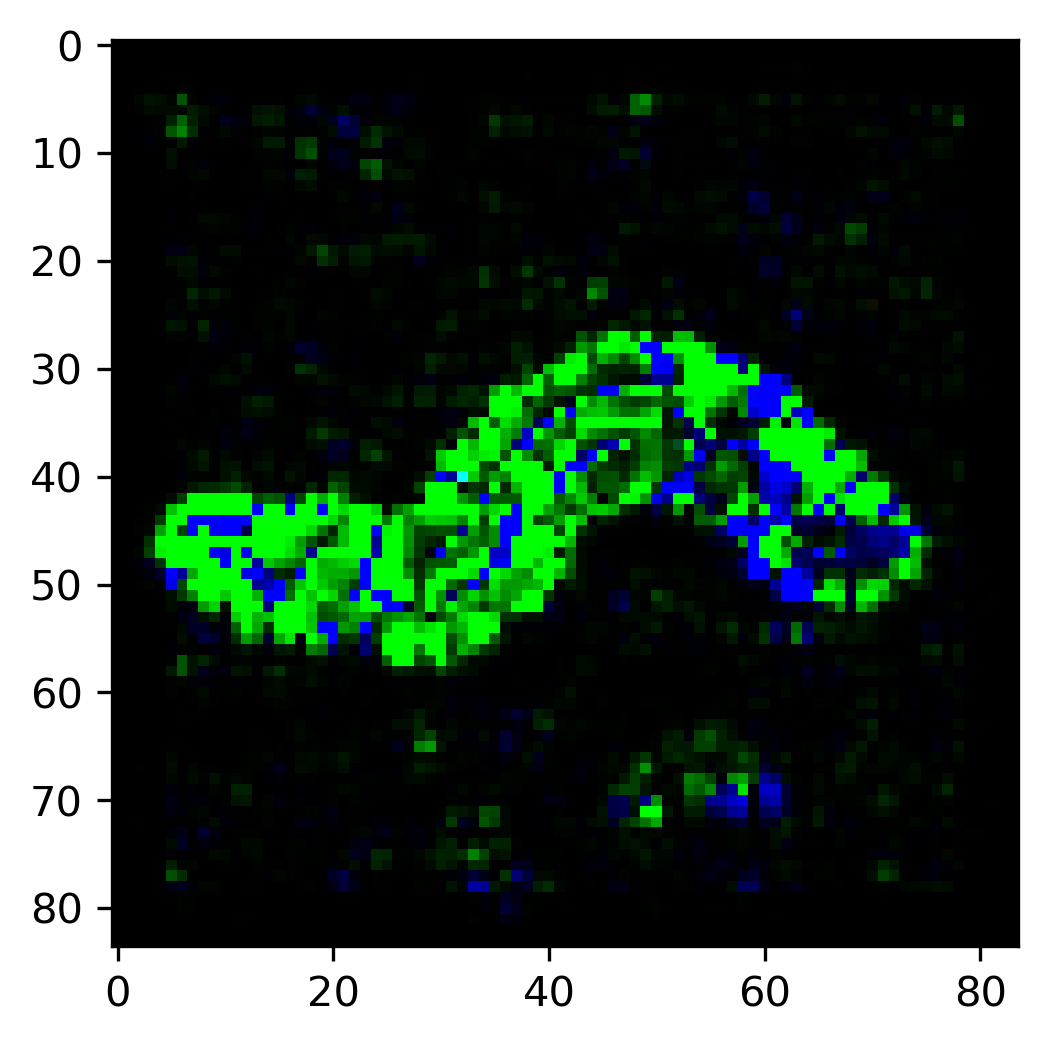

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


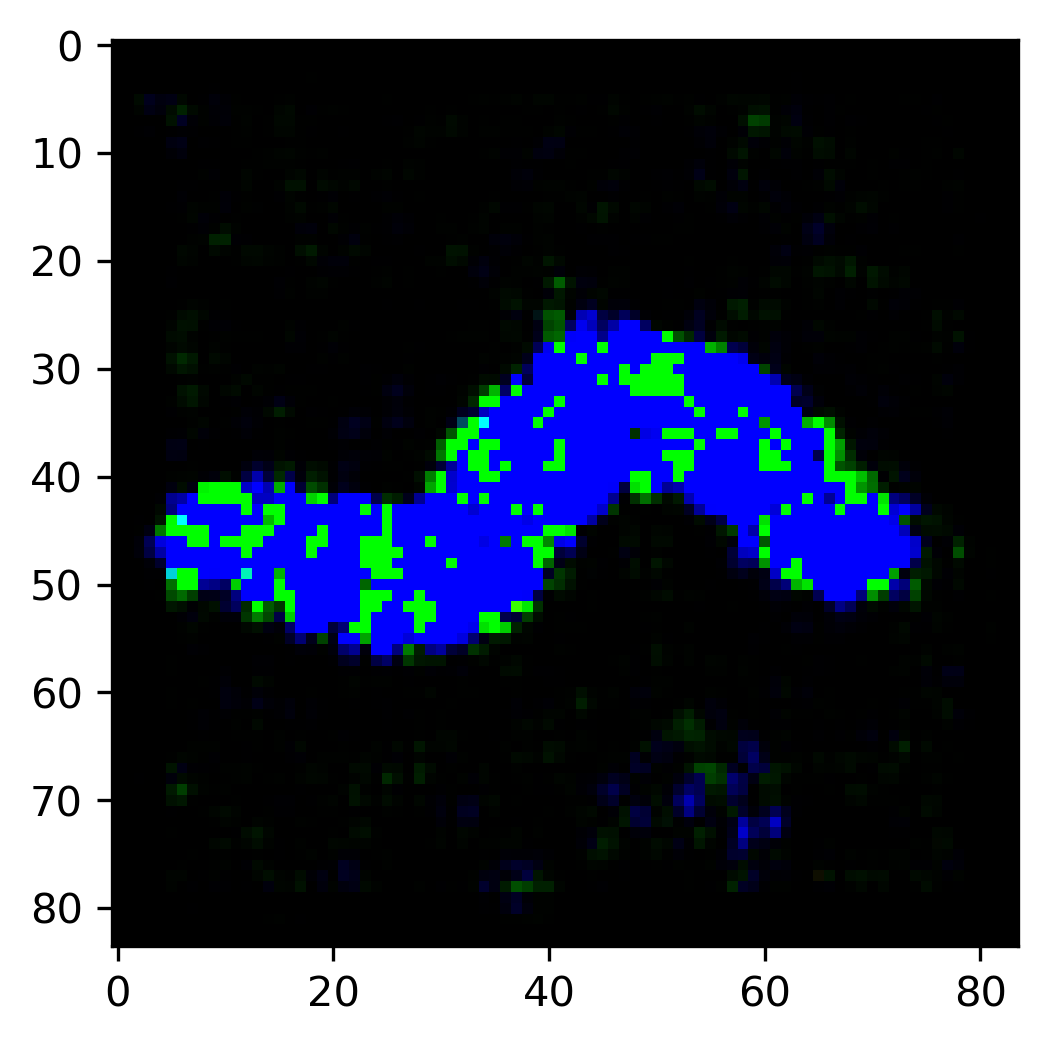

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


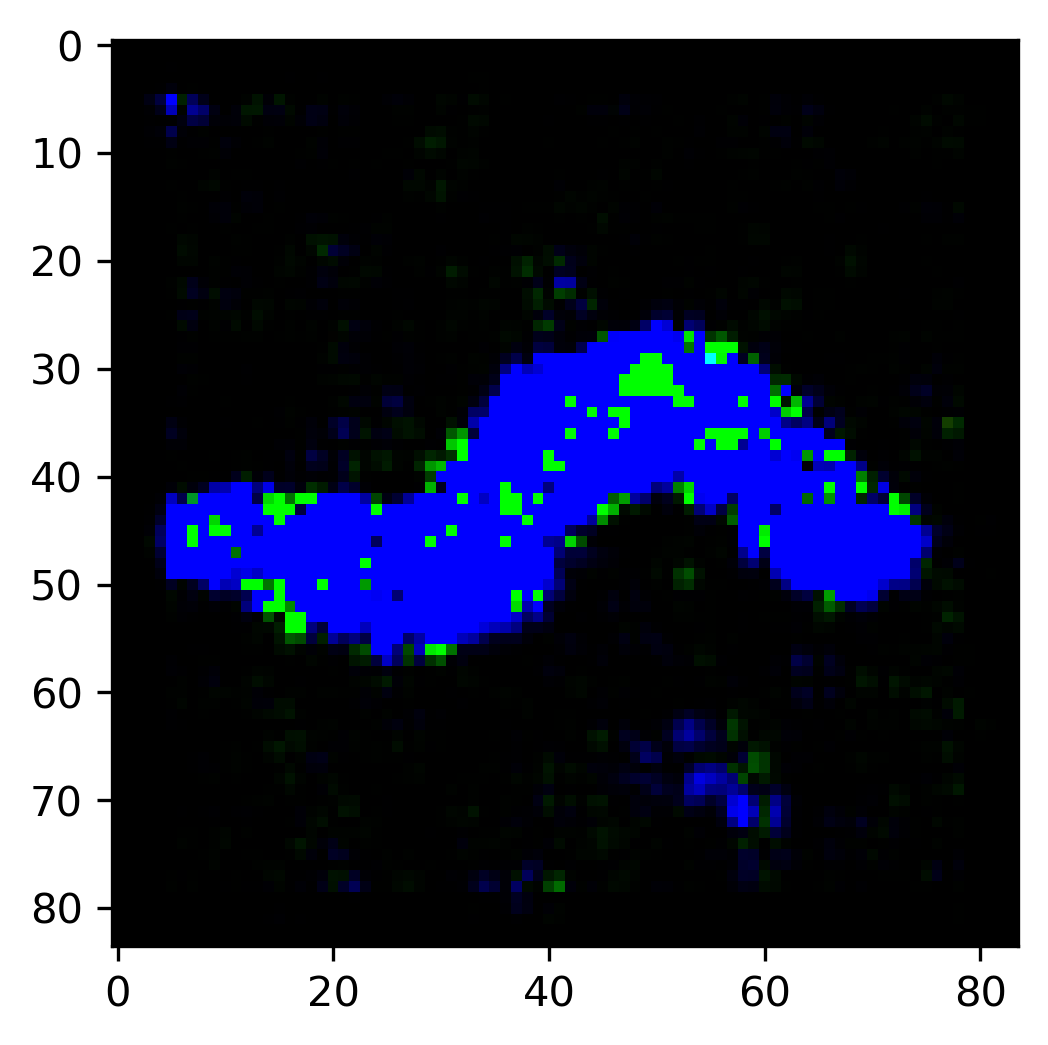

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


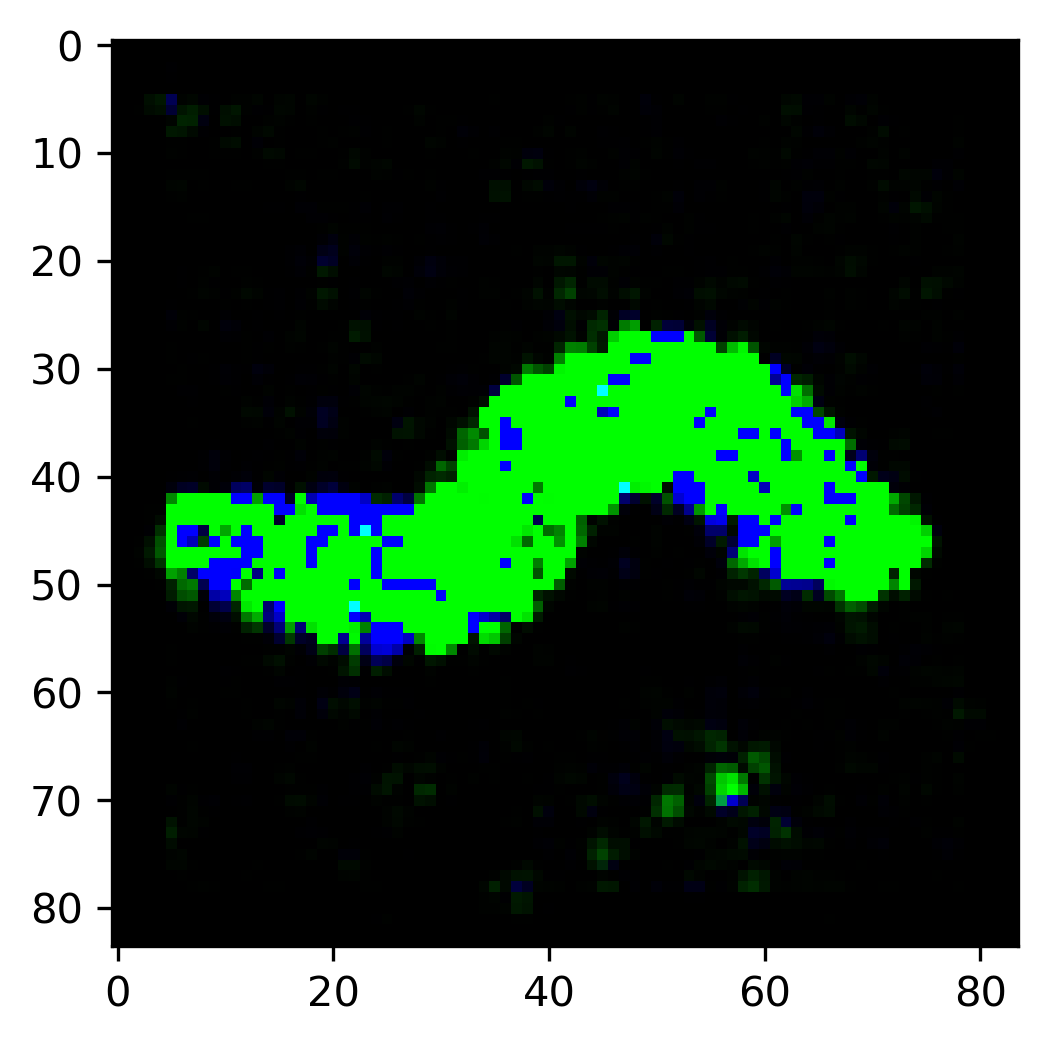

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


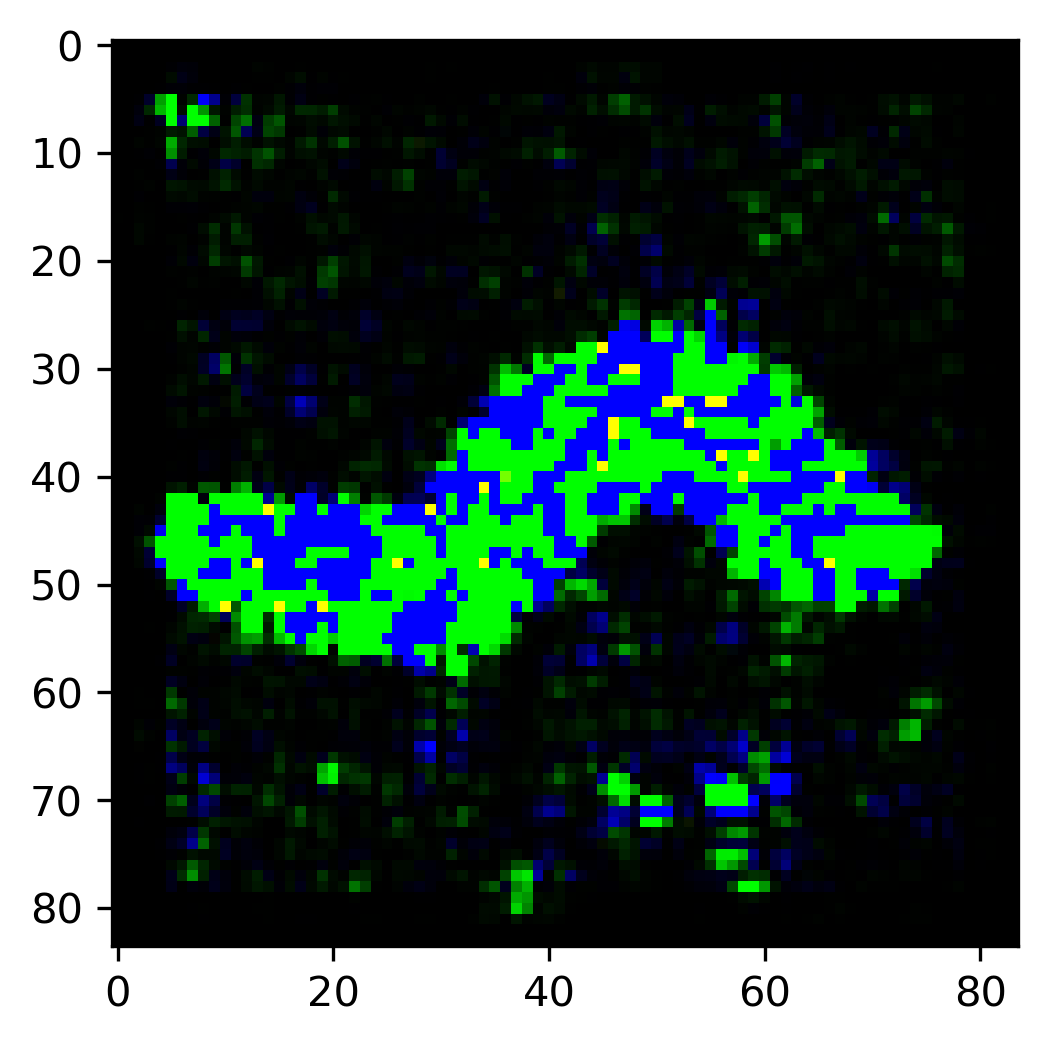

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


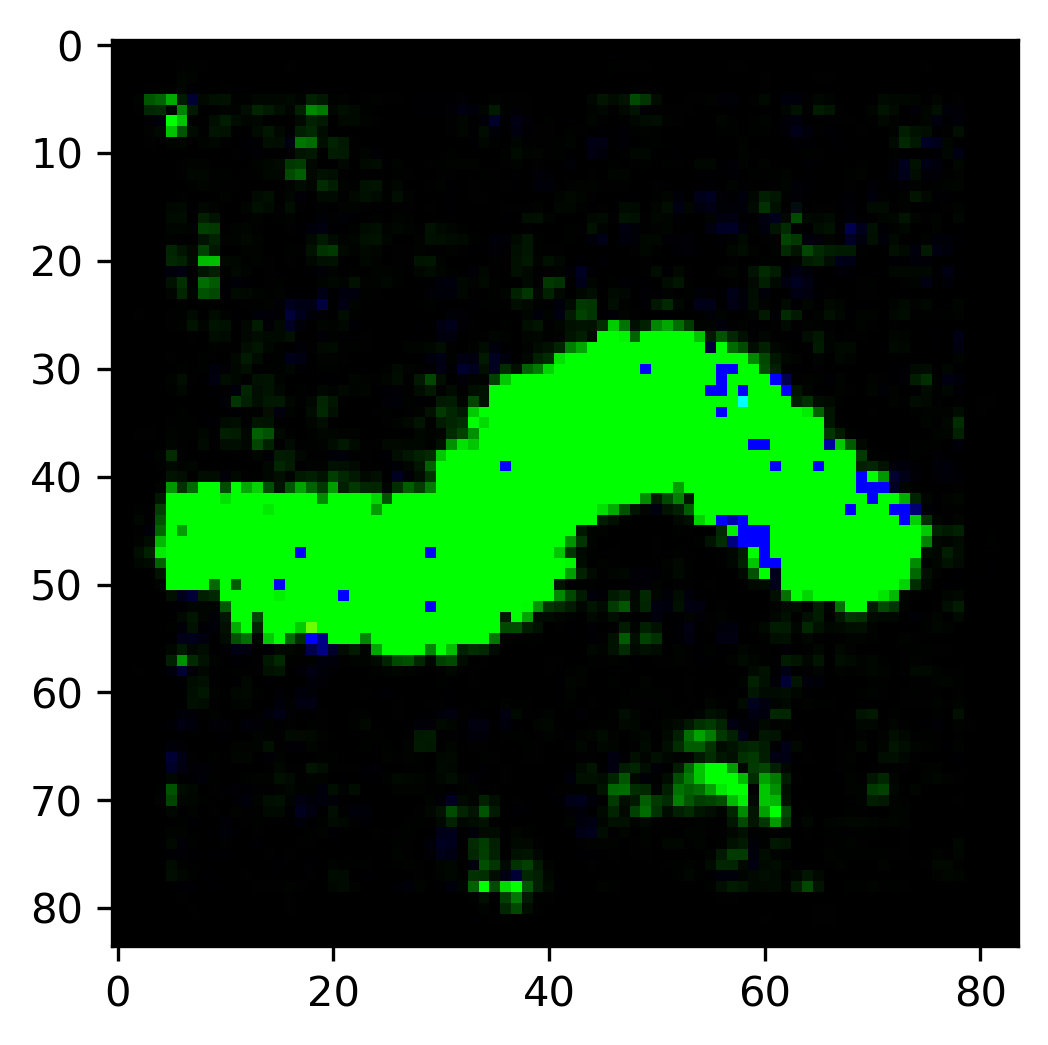

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


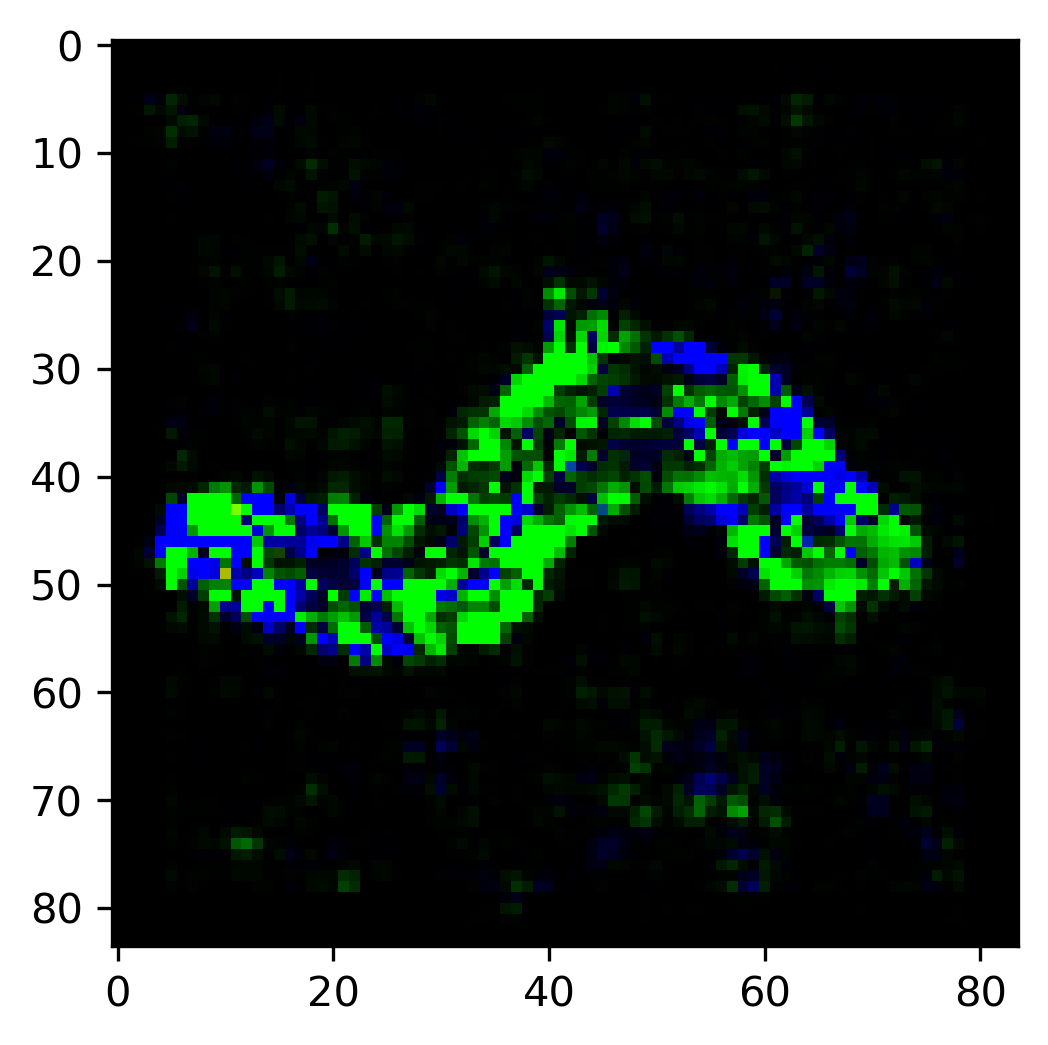

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


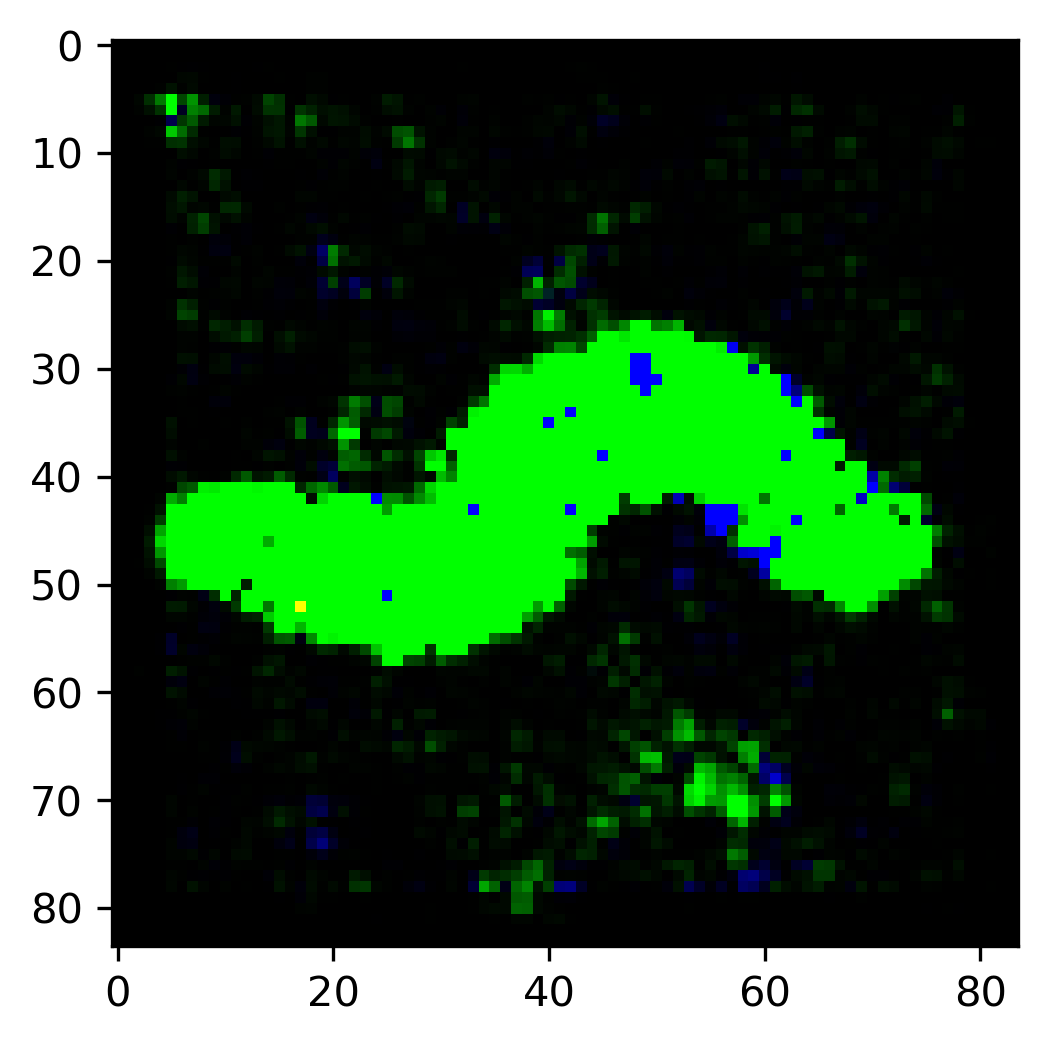

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


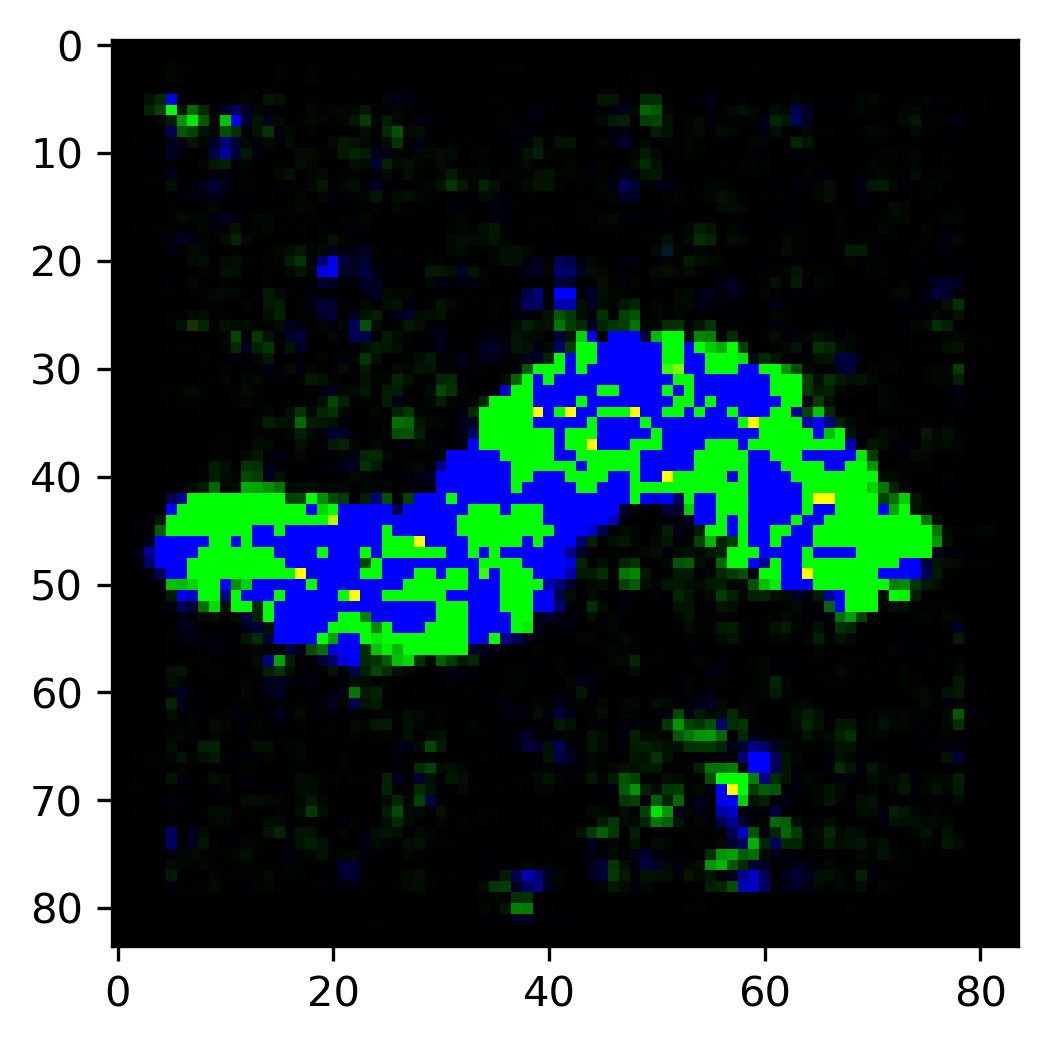

hello 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


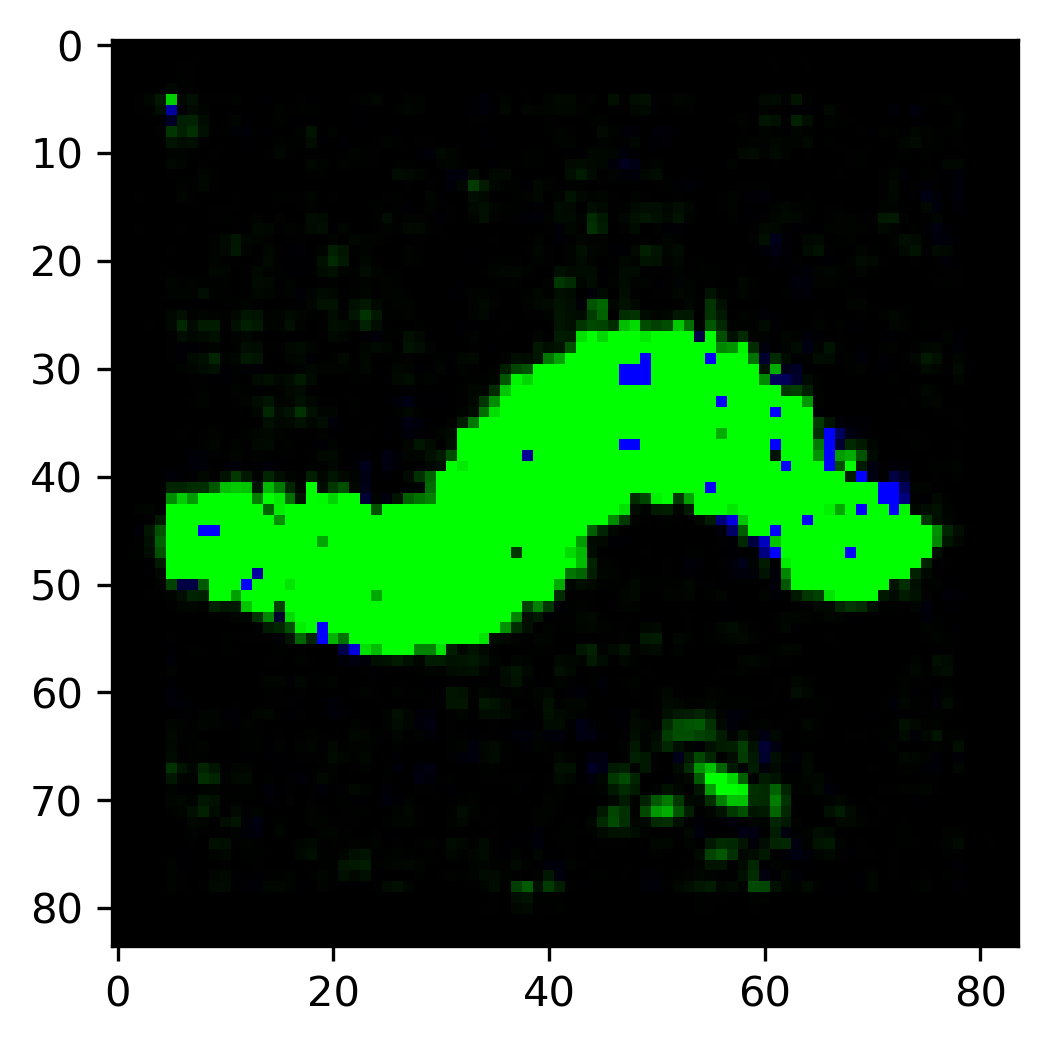

hello 


In [207]:
hsv = np.zeros(img[0].shape+(3,))
hsv[...,1] = 255
frame_shift = 5
for frame_idx in range(0,total_frames-frame_shift):
    if frame_idx<60 or frame_idx>80:
        continue

    next_frame_idx = frame_idx+frame_shift

    frame = img[frame_idx]
#     bin_frame = bin_img[frame_idx]
#     dilated_bin_frame  = cv2.dilate(bin_frame,kernel,iterations=2)
#     frame_masked = cv2.bitwise_and(frame,dilated_bin_frame)

    next_frame_raw = img[next_frame_idx]
    
    flow = cv2.calcOpticalFlowFarneback(frame,next_frame_raw,flow=None, pyr_scale=0.5,levels= 3, winsize=1, iterations=3, poly_n=3, poly_sigma=1.8, flags=0)
    mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
    hsv[...,0] = (ang*180/np.pi/2)
    hsv[...,2] = cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX)
    flow_image = cv2.cvtColor(hsv.astype('float32'),cv2.COLOR_HSV2BGR)
    plt.figure(dpi=300)
    plt.imshow(flow_image)
    plt.show()
    x = input("hello")
#     next_frame_bin_raw = bin_img[next_frame_idx]
#     next_frame_bin_fixed = get_fixed_crop_based_on_centroid(bin_frame,next_frame_bin_raw,centroid,next_centroid,debug=False)
#     dilated_next_frame_bin_fixed = cv2.dilate(next_frame_bin_fixed,kernel,iterations=2)
#     next_frame_masked = cv2.bitwise_and(next_frame_fixed,dilated_next_frame_bin_fixed)

    
#     result_frame = frame_masked-next_frame_masked
#     eroded_dilated_bin_frame = cv2.erode(dilated_bin_frame,kernel,iterations=1)
#     masked_output_frame = cv2.bitwise_or(result_frame,result_frame,mask=eroded_dilated_bin_frame.astype(np.uint8))
#     plt.imshow(masked_output_frame,cmap='PiYG')




In [167]:
hsv[...,0].max()

179.9669952392578

In [116]:
masked_output_frame.min()

0

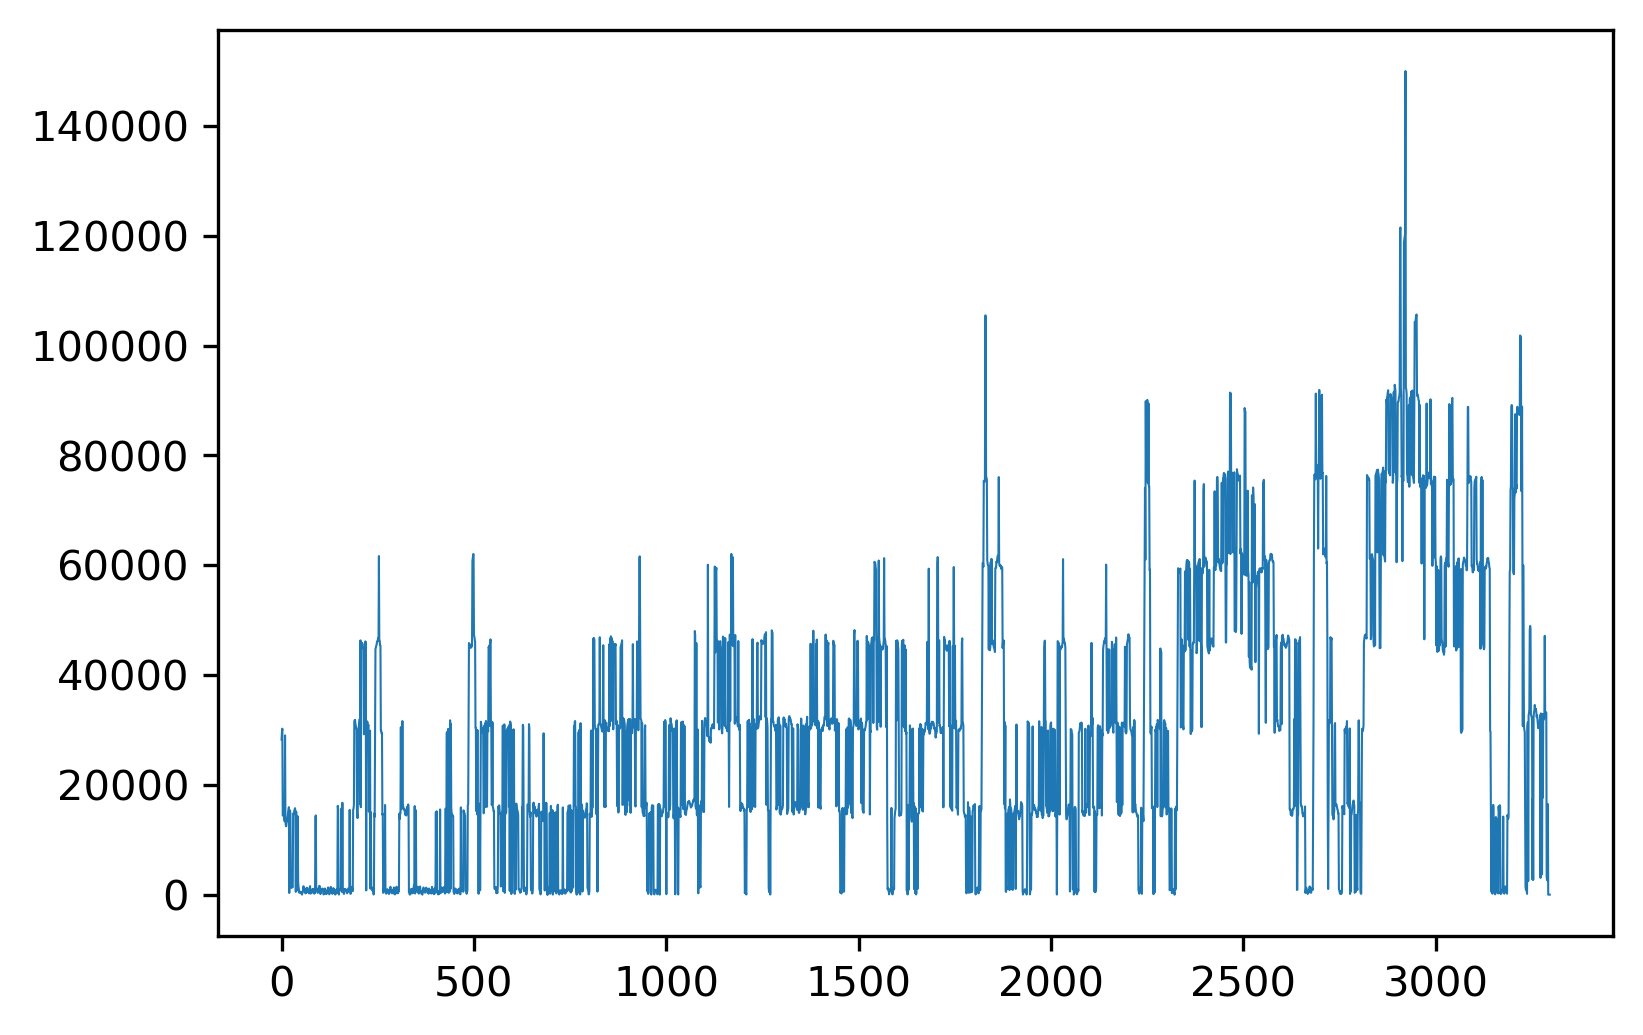

In [77]:
plt.figure(dpi=300)
plt.plot(results_arr,linewidth=0.5)

In [63]:
avi_path = r'C:\Temp\quiescence\quiescence_analysis\cropped_worm44.avi'

def load_avi(input_filename: str,fps:int=10):
    """
    this function uses tiffile package to load a tiff file to memory
    :param filepath: str, path to the binarized image file
    :return:
    loaded numpy img object
    """
    cap = cv2.VideoCapture(input_filename)
    # Get frame count
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) 

    # Get width and height of video stream
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Define the codec for output video
    fourcc = cv2.VideoWriter_fourcc('M','J','P','G')

    # Set up output video
    out = cv2.VideoWriter('video_out.mp4', fourcc, fps, (w, h))

    # Read first frame
    shape = (n_frames,) + (w,h)
    img = np.empty(shape, dtype=np.int16)
        
    for idx in range(n_frames):
        #read frame
        _, prev = cap.read() 

        # Convert frame to grayscale
        prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
        
        #append
        img[idx] = prev_gray

    return img

avi = load_avi(avi_path)


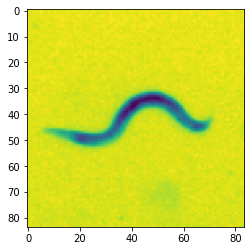

In [9]:
img_path = r'C:\Temp\quiescence\quiescence_analysis\cropped_worm44_binarized.tiff'
img = load_tiff(img_path)
ind=44
total_frames = mat["Tracks"]["Path"][0,ind].shape[0]
frame_shift = 5
from quiescence_analysis.src.quiescence_analysis import calculate_pixel_diff 

def get_frame_diff_fixed_crop(img_path, frame_shift: int = 3, norm_size_threshold: float = 0.4,ind:int=44,debug:bool=False):
    """
    Calculates difference in pixels between two time points
    it recieves a binarized image and outputs a numpy array of pixel_diffs

    Parameters:
    ----------
    img:nd.array
        8 bit binarized image series
    frame_shift:int
        shift in time to calculate pixel difference
    norm_size_threshold: float
        threshold to remove small object noise
    """

    # get reference size
    ref_size = get_average_ref_area(img_path,fraction_frames=0.1)
    tiff_read_buffer = frame_shift + 1
    if debug: print("ref size is",ref_size)

    # read binarized image in a buffered manner
    with tiff.TiffFile(img_path) as tif:
        # get tiff stats
        frames_num = len(tif.pages)
        img_temp = tif.pages[0].asarray()
        img_shape = (tiff_read_buffer,) + (img_temp.shape)
        if debug:print("image shape",img_shape)
        if debug:print("frame num",frames_num)
        # initialize
        # -buffered img
        img = np.zeros(img_shape, dtype=np.int16)

        # -array to hold the results
        frame_diff_arr = np.zeros(frames_num)
        frame_diff_arr[:] = np.nan

        # iterate over frames
        for idx, page in enumerate(tif.pages):
            if debug: print("idx",idx)
            # preload first batch of stacks
            if idx < tiff_read_buffer - 1:
                img[idx] = page.asarray()
                if debug: print("idx skip", idx)
                continue

            # get idx for two frames to compare
            if idx == frames_num-frame_shift:
                if debug: print("idx is",idx,"stopped")
                break

            jdx = idx + 1
            frame_assign_idx = idx % tiff_read_buffer
            frame_reference_idx = jdx % tiff_read_buffer
            next_frame_idx = (tiff_read_buffer + jdx - 1) % tiff_read_buffer

            # insert frame
            img[frame_assign_idx] = page.asarray()
            if debug: print("frames set")
            # define frames to compare
            frame = img[frame_reference_idx]
            next_frame = img[next_frame_idx]
            
            centroid = (mat["Tracks"]["Path"][0,ind][idx,0],mat["Tracks"]["Path"][0,ind][idx,1])
            next_centroid = (mat["Tracks"]["Path"][0,ind][idx+frame_shift,0],mat["Tracks"]["Path"][0,ind][idx+frame_shift,1])

            next_frame_fixed = get_fixed_crop_based_on_centroid(frame,next_frame,centroid,next_centroid,debug=debug)

            if debug: print("function called")
                
            # calculate pixel diff
            curr_pixel_diff = calculate_pixel_diff(frame, next_frame_fixed, ref_size, norm_size_threshold,debug=debug)
            if debug: print("current idx",idx,"pixel_diff",curr_pixel_diff)
            # save pixel diff into array
            frame_diff_arr[idx] = curr_pixel_diff

    # remove NaNs
    frame_diff_arr = frame_diff_arr[~np.isnan(frame_diff_arr)]

    return frame_diff_arr

In [252]:
frame_diff = get_frame_diff(img_path, frame_shift=5, norm_size_threshold=1,ind=44,debug=False)

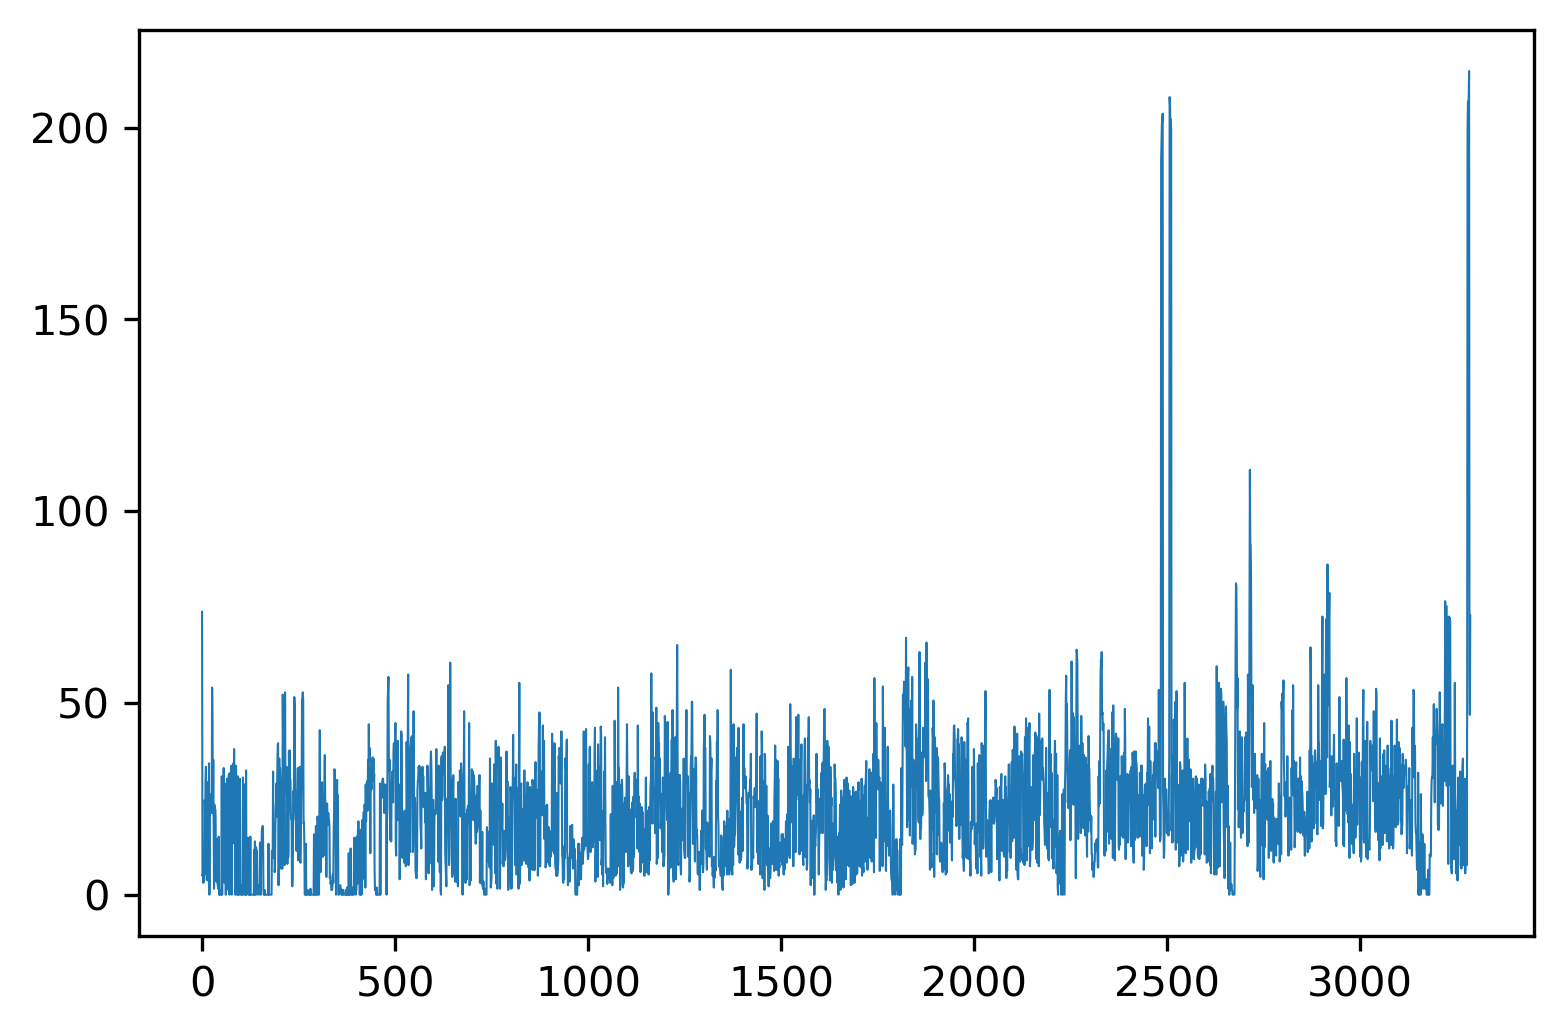

In [253]:
plt.figure(dpi=300)
plt.plot(frame_diff,linewidth=0.5)

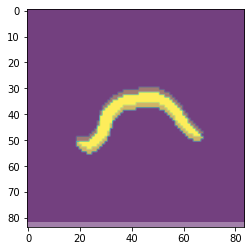

In [152]:
plt.imshow(img[frame+frame_shift][-round(diff_x):,-round(diff_y):],alpha=0.5)
plt.imshow(img[frame+frame_shift],alpha=0.5)

In [118]:
# num_individuals = mat['Tracks'][0].shape[0]
# for i in range(0,num_individuals):
#     print("individual ",i)
#     print("size",mat['Tracks'][0][i][16].shape)

individual  0
size (1, 5998)
individual  1
size (1, 1187)
individual  2
size (1, 1187)
individual  3
size (1, 608)
individual  4
size (1, 1264)
individual  5
size (1, 1264)
individual  6
size (1, 608)
individual  7
size (1, 2043)
individual  8
size (1, 730)
individual  9
size (1, 2149)
individual  10
size (1, 3040)
individual  11
size (1, 778)
individual  12
size (1, 614)
individual  13
size (1, 769)
individual  14
size (1, 513)
individual  15
size (1, 761)
individual  16
size (1, 1226)
individual  17
size (1, 3911)
individual  18
size (1, 784)
individual  19
size (1, 1085)
individual  20
size (1, 1162)
individual  21
size (1, 1162)
individual  22
size (1, 1274)
individual  23
size (1, 986)
individual  24
size (1, 1899)
individual  25
size (1, 1327)
individual  26
size (1, 1234)
individual  27
size (1, 678)
individual  28
size (1, 788)
individual  29
size (1, 1518)
individual  30
size (1, 1026)
individual  31
size (1, 2718)
individual  32
size (1, 6942)
individual  33
size (1, 2691)
in

In [108]:
for i in range mat['Tracks'][0][0][16].shape

(1, 1740)

In [6]:
centroid_df = pd.read_hdf(centroid_path)


In [48]:
centroid_df.to_csv('output.csv')

In [33]:
x = ~np.isnan(centroid_df['individual44']['centroid']['x']['2'])

In [37]:
x[x==True]

Series([], Name: 2, dtype: bool)

In [25]:
first_frame_index = centroid_df['individual44']['centroid']['x']['1'].first_valid_index()

In [26]:
first_frame_index

In [7]:
import cv2
fps = 10

cap = cv2.VideoCapture(avi_path)
# Get frame count
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) 

# Get width and height of video stream
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Define the codec for output video
fourcc = cv2.VideoWriter_fourcc('M','J','P','G')

# Set up output video
out = cv2.VideoWriter('video_out.mp4', fourcc, fps, (w, h))

# Read first frame
_, prev = cap.read() 

# Convert frame to grayscale
prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

# Pre-define transformation-store array
transforms = np.zeros((n_frames-1, 3), np.float32) 

for i in range(n_frames-2):
    # Detect feature points in previous frame
    prev_pts = cv2.goodFeaturesToTrack(prev_gray,
                                     maxCorners=200,
                                     qualityLevel=0.01,
                                     minDistance=30,
                                     blockSize=3)

    # Read next frame
    success, curr = cap.read()
    if not success:
        break 

    # Convert to grayscale
    curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY) 

    # Calculate optical flow (i.e. track feature points)
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None) 

    # Sanity check
    assert prev_pts.shape == curr_pts.shape 

    # Filter only valid points
    idx = np.where(status==1)[0]
    prev_pts = prev_pts[idx]
    curr_pts = curr_pts[idx]

    #Find transformation matrix
    m = cv2.estimateRigidTransform(prev_pts, curr_pts, fullAffine=False) #will only work with OpenCV-3 or less
#     m = m[0]
    # Extract traslation
    if m is not None:
        dx = m[0,2]
        dy = m[1,2]
    else:
        continue

    # Extract rotation angle
    da = np.arctan2(m[1,0], m[0,0])

    # Store transformation
    transforms[i] = [dx,dy,da]

    # Move to next frame
    prev_gray = curr_gray

    print("Frame: " + str(i) +  "/" + str(n_frames) + " -  Tracked points : " + str(len(prev_pts)))
    

def movingAverage(curve, radius):
    window_size = 2 * radius + 1
    # Define the filter
    f = np.ones(window_size)/window_size
    # Add padding to the boundaries
    curve_pad = np.lib.pad(curve, (radius, radius), 'edge')
    # Apply convolution
    curve_smoothed = np.convolve(curve_pad, f, mode='same')
    # Remove padding
    curve_smoothed = curve_smoothed[radius:-radius]
    # return smoothed curve
    return curve_smoothed

def smooth(trajectory):
    smoothed_trajectory = np.copy(trajectory)
    # Filter the x, y and angle curves
    for i in range(3):
        smoothed_trajectory[:,i] = movingAverage(trajectory[:,i], radius=3)

    return smoothed_trajectory

# Compute trajectory using cumulative sum of transformations
trajectory = np.cumsum(transforms, axis=0)

smoothed_trajectory = smooth(trajectory)

# Calculate difference in smoothed_trajectory and trajectory
difference = smoothed_trajectory - trajectory

# Calculate newer transformation array
transforms_smooth = transforms + difference

# Reset stream to first frame
cap.set(cv2.CAP_PROP_POS_FRAMES, 0) 

# Write n_frames-1 transformed frames
for i in range(n_frames-2):
    # Read next frame
    success, frame = cap.read()
    if not success:
        break

    # Extract transformations from the new transformation array
    dx = transforms_smooth[i,0]
    dy = transforms_smooth[i,1]
    da = transforms_smooth[i,2]

    # Reconstruct transformation matrix accordingly to new values
    m = np.zeros((2,3), np.float32)
    m[0,0] = np.cos(da)
    m[0,1] = -np.sin(da)
    m[1,0] = np.sin(da)
    m[1,1] = np.cos(da)
    m[0,2] = dx
    m[1,2] = dy

    # Apply affine wrapping to the given frame
    frame_stabilized = cv2.warpAffine(frame, m, (w,h))

    # Fix border artifacts
#     frame_stabilized = fixBorder(frame_stabilized) 

    # Write the frame to the file
    frame_out = cv2.hconcat([frame, frame_stabilized])

    # If the image is too big, resize it.
#     if(frame_out.shape[1] &gt; 1920):
#         frame_out = cv2.resize(frame_out, (frame_out.shape[1]/2, frame_out.shape[0]/2));

#     cv2.imshow("Before and After", frame_out)
#     cv2.waitKey(10)
    out.write(frame_stabilized)
    
def fixBorder(frame):
    s = frame.shape
    # Scale the image 4% without moving the center
    T = cv2.getRotationMatrix2D((s[1]/2, s[0]/2), 0, 1.04)
    frame = cv2.warpAffine(frame, T, (s[1], s[0]))
    return frame


Frame: 0/3297 -  Tracked points : 3
Frame: 1/3297 -  Tracked points : 3
Frame: 2/3297 -  Tracked points : 3
Frame: 3/3297 -  Tracked points : 3
Frame: 4/3297 -  Tracked points : 4
Frame: 5/3297 -  Tracked points : 3
Frame: 6/3297 -  Tracked points : 3
Frame: 7/3297 -  Tracked points : 3
Frame: 8/3297 -  Tracked points : 4
Frame: 9/3297 -  Tracked points : 4
Frame: 10/3297 -  Tracked points : 4
Frame: 11/3297 -  Tracked points : 4
Frame: 12/3297 -  Tracked points : 4
Frame: 13/3297 -  Tracked points : 4
Frame: 14/3297 -  Tracked points : 4
Frame: 15/3297 -  Tracked points : 4
Frame: 16/3297 -  Tracked points : 4
Frame: 17/3297 -  Tracked points : 4
Frame: 18/3297 -  Tracked points : 3
Frame: 19/3297 -  Tracked points : 4
Frame: 20/3297 -  Tracked points : 3
Frame: 21/3297 -  Tracked points : 4
Frame: 22/3297 -  Tracked points : 4
Frame: 23/3297 -  Tracked points : 4
Frame: 24/3297 -  Tracked points : 4
Frame: 25/3297 -  Tracked points : 4
Frame: 26/3297 -  Tracked points : 6
Frame: 27/3

In [24]:
m

0.005152085742639272

#### plot ####

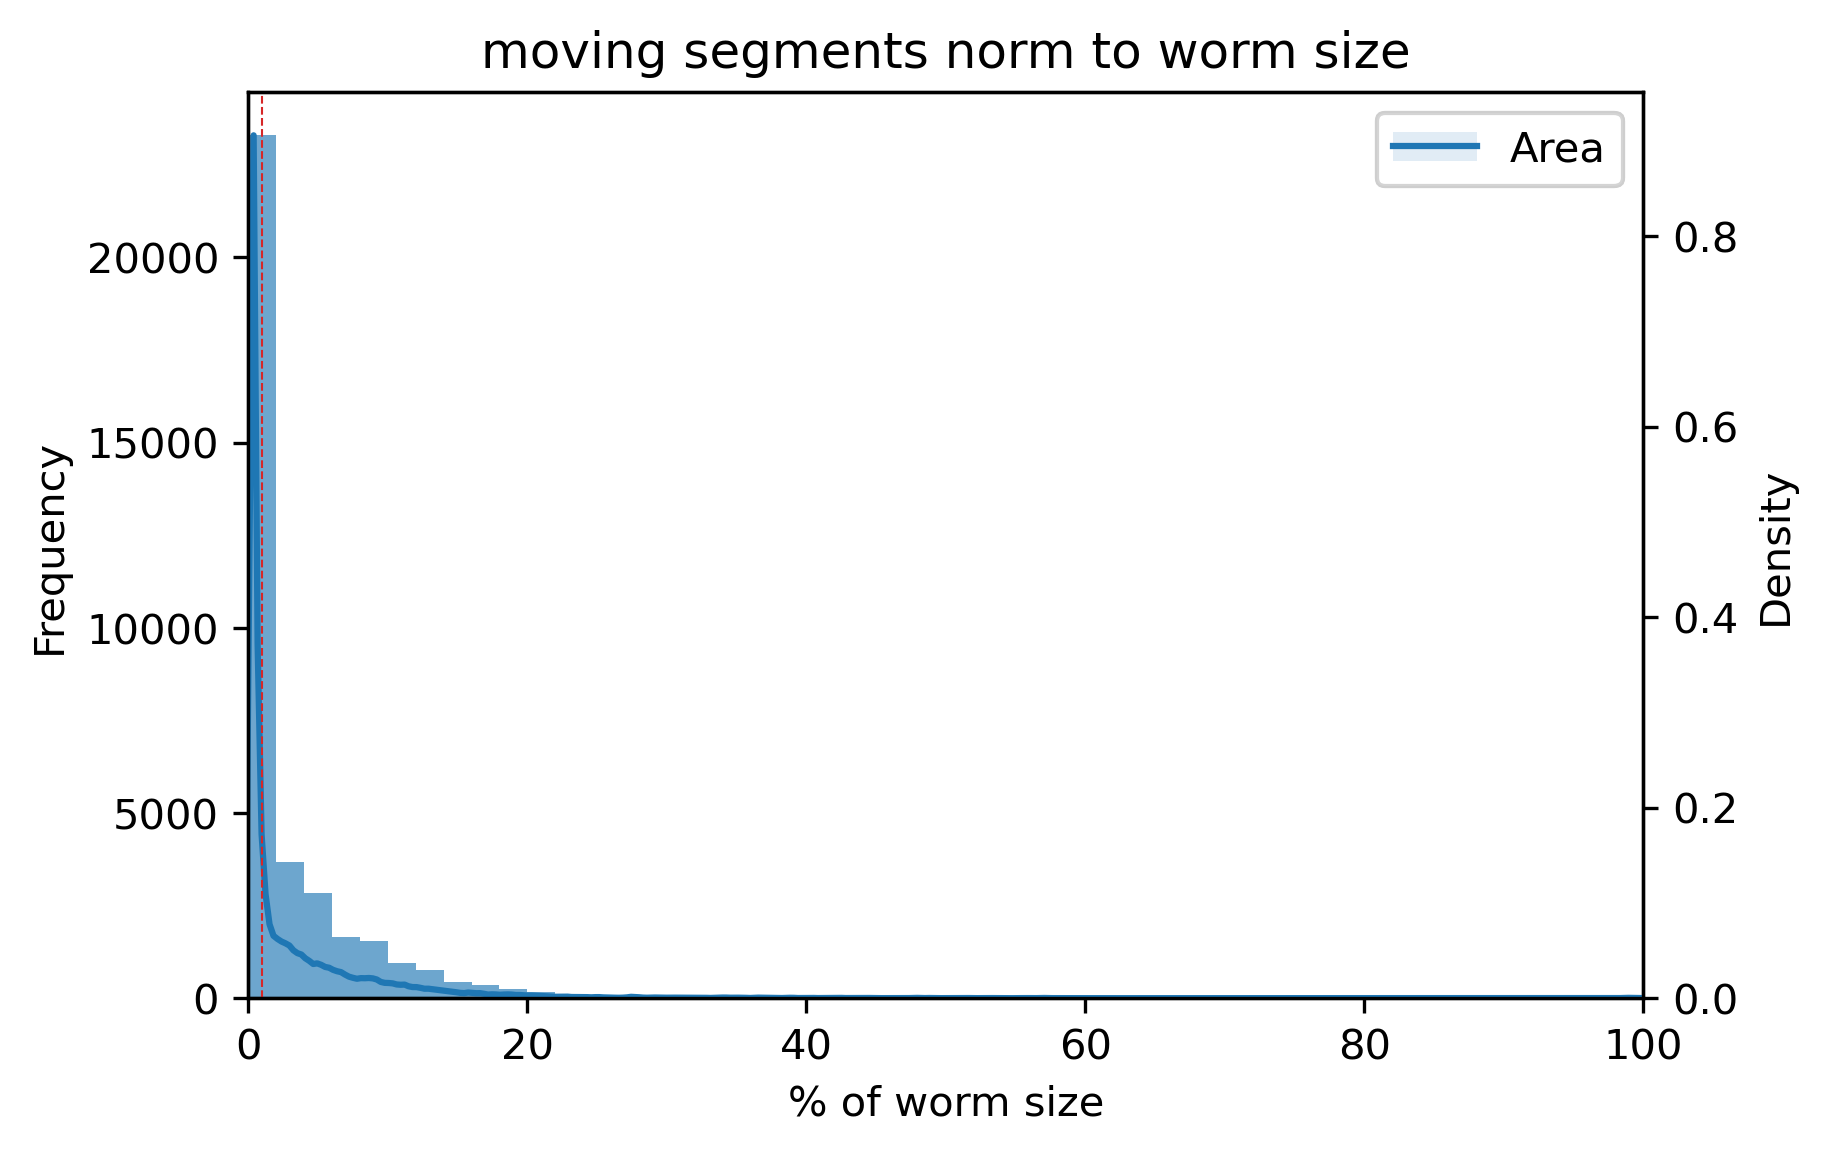

----------------------------------------------------------------------------------------------


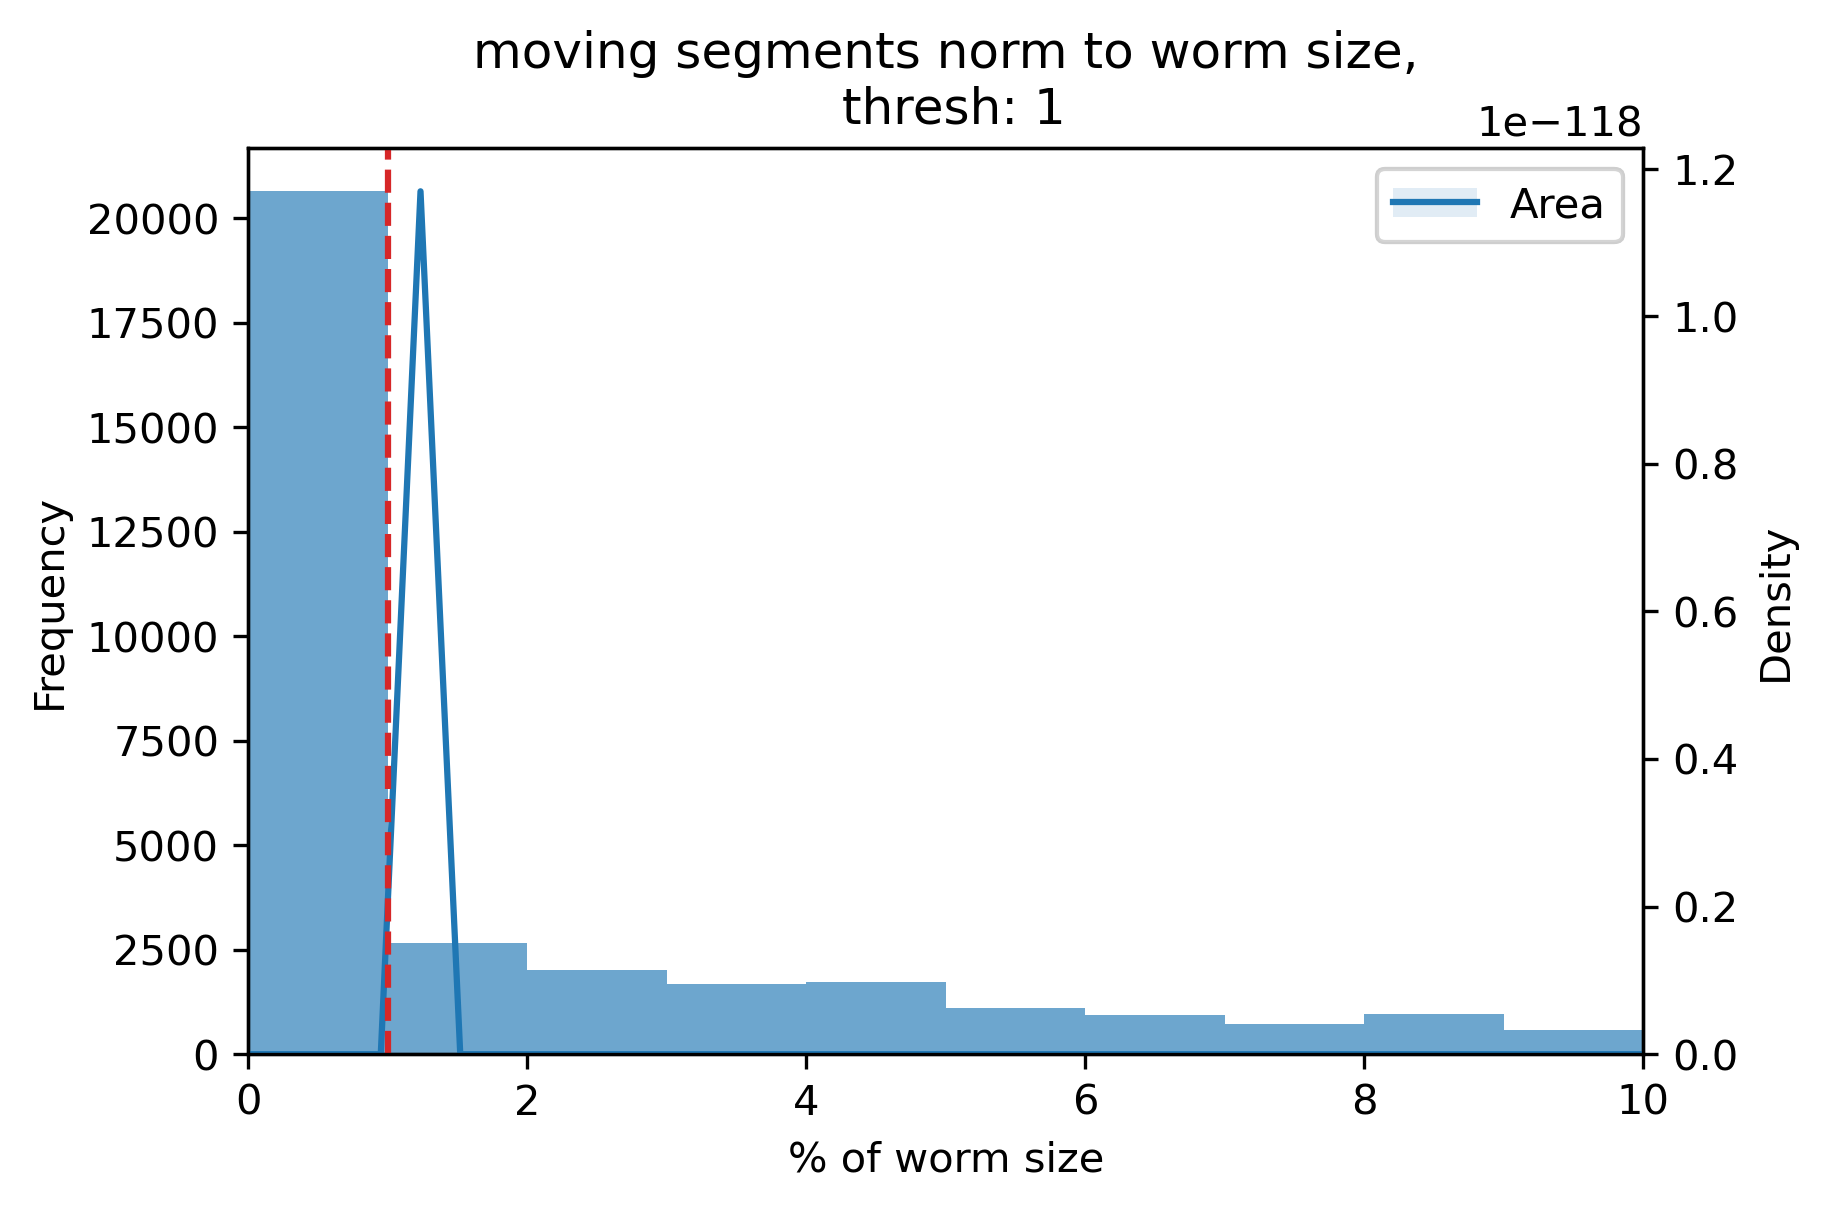

In [26]:
import pandas as pd
%matplotlib inline
fig,ax = plt.subplots(dpi=300)
norm_stats_area = (stats_area/worm_size)*100
stats_area_df = pd.DataFrame(norm_stats_area, columns = ['Area'])
# Plot
range_max = 100
bins_num = 50
stats_area_df.plot(kind = "hist", density = False, alpha = 0.65, bins = bins_num,range=(0,range_max),ax=ax) # change density to true, because KDE uses density
ax2 = ax.twinx()
stats_area_df.plot(kind = "kde",bw_method=0.03,ax=ax2)
ax.set_xlim(0,range_max)
ax2.set_title('moving segments norm to worm size')
ax.set_xlabel('% of worm size')
ax2.set_ylim(0,)
plt.axvline(x=size_threshold, color='tab:red', linestyle='--',linewidth=0.5)
plt.show()
print('----------------------------------------------------------------------------------------------')
fig,ax = plt.subplots(dpi=300)
range_max = 10
bins_num = 10
stats_area_df.plot(kind = "hist", density = False, alpha = 0.65, bins = bins_num,range=(0,range_max),ax=ax) # change density to true, because KDE uses density
ax2 = ax.twinx()
stats_area_df.plot(kind = "kde",bw_method=0.000001,ax=ax2)
ax.set_xlim(0,range_max)
ax2.set_title('moving segments norm to worm size,\n thresh: '+str(size_threshold))
ax.set_xlabel('% of worm size')
ax2.set_ylim(0,)
plt.axvline(x=size_threshold, color='tab:red', linestyle='--')

plt.show()


### Backup ###

In [ ]:
# planing of buffer readnig of tiff
buffer = 4
for i in range(0,100):
    if i<buffer:
        continue
    print("----------------------idx = ",i,"-----------------------------")
    print("pos",(i%buffer),"compare with pos",(buffer+i-1)%buffer)
    print("but you should compare")
    j=i+1
    print("pos",(j%buffer),"compare with pos",(buffer+j-1)%buffer)
    
    

In [ ]:
#playing to design the pixel diff function
output_path = r'C:\Temp\quiescence\quiescence_analysis\pixel_diff_5_worm_example.tiff'
def get_frame_diff(img_path,frame_shift:int=3, norm_size_threshold:float=0.4):
    """
    Calculates difference in pixels between two time points
    it recieves a binarized image and outputs a numpy array of pixel_diffs
    
    Parameters:
    ----------
    img:nd.array
        8 bit binarized image series
    frame_shift:int
        shift in time to calculate pixel difference
    norm_size_threshold: float
        threshold to remove small object noise
    """
    #get reference size
#     ref_size = get_average_worm_area(img=img,fraction_frames=0.1)
    ref_size = 369.6685
    tiff_read_buffer = frame_shift + 1
    
    #read binarized image in a buffered manner
    with tiff.TiffFile(img_path) as tif:
        #get tiff stats
        frames_num = len(tif.pages)
        img_temp = tif.pages[0].asarray()
        img_shape = (tiff_read_buffer,) + (img_temp.shape)

        #initialize 
        #-buffered img
        img = np.zeros(img_shape, dtype=np.int16)

        #-array to hold the results
        frame_diff_arr = np.zeros(frames_num)
        frame_diff_arr[:] = np.nan

        #iterate over frames
        for idx,page in enumerate(tif.pages):

            #preload first batch of stacks
            if idx<tiff_read_buffer-1:
                img[idx] = page.asarray()
                continue

            #get idx for two frames to compare
            if idx==frames_num:
                break

            jdx = idx+1

            frame_assign_idx = idx%tiff_read_buffer
            frame_reference_idx = jdx%tiff_read_buffer
            next_frame_idx = (tiff_read_buffer+jdx-1)%tiff_read_buffer
#                 print("pos",(i%buffer),"compare with pos",(buffer+i-1)%buffer)
#     print("but you should compare")
#     j=i+1
#     print("pos",(j%buffer),"compare with pos",(buffer+j-1)%buffer)

            #load rest of stacks buffered

            img[frame_assign_idx] = page.asarray()
#             print("abs. frame",idx,"was put in ",frame_assign_idx)
#             print("absolute frame is",idx,"compare frame", frame_reference_idx,"with frame",next_frame_idx)

            #load two relevent frames
            frame = img[frame_reference_idx]
            next_frame = img[next_frame_idx]

#             print("------------------------FRAME - ",idx,"-------------------")

#             fig = plt.imshow(next_frame-frame,cmap='RdBu')
# #                 tif_writer.save(next_frame-frame)
#             plt.show()

            #calculate pixel diff
            curr_pixel_diff = calculate_pixel_diff(frame,next_frame,ref_size,norm_size_threshold)

            #save pixel diff into array
            frame_diff_arr[idx] = curr_pixel_diff
        #remove NaNs
    #     frame_diff_arr = frame_diff_arr[~np.isnan(frame_diff_arr)]
    
    return frame_diff_arr

In [21]:
import os
def find_matching_file(file_path, dir_ext: str = 'h5',
                       file_ext: str = 'DLC_resnet50_coverslip_HRDec10shuffle1_1030000.h5',
                       worm_file: bool = True,
                       debug: bool = False):
    """
    Finds the matching worm file from the experiment folder
    its goes one folder up to get to root folder, and looks inside another folder
    """

    root_folder_path = os.path.dirname(os.path.dirname(file_path))

    folder_path = os.path.join(root_folder_path,dir_ext)

    worm_num_re = re.search('(?<=worm_)(\d+)', file_path)
    if worm_num_re is None and worm_file:
        worm_num_re = re.search('(?<=worm)(\d+)', file_path)
    if worm_num_re is None and worm_file:
        if debug:
            print("couldn't find matching worm file because worm number was not found in")
            print(folder_path)
        return None
    elif worm_file:
        worm_num = int(worm_num_re[0])
    else:
        worm_num = ''

    # file_end = "_worm"+str(worm_num)+file_ext
    filenames = os.listdir(folder_path)

    if worm_file:
        matching_file_worm_num = [f for f in filenames if "_worm" + str(worm_num) in f]
        if len(matching_file_worm_num) < 1:
            matching_file_worm_num = [f for f in filenames if "_worm_" + str(worm_num) in f]
            if len(matching_file_worm_num) < 1:
                if debug:
                    print("couldn't find matching file, no worm in files")
                return None
    else:
        matching_file_worm_num = filenames

    matching_files = [f for f in matching_file_worm_num if f.endswith(file_ext)]

    if len(matching_files) < 1:
        if debug: print("couldn't find matching file, ending: ",file_ext," is missing")
        return None


    matching_file_path = os.path.join(folder_path,matching_files[0])

    if os.path.exists(matching_file_path) == False:
        if debug: print("matching file was not found ending with:", file_ext)
        return None

    return matching_file_path

In [22]:
file = 'C:\Temp\quiescence\quiescence_analysis\quiescence_analysis\dev\cropped_worm1DLC_resnet50_coverslip_HRDec10shuffle1_1030000_filtered.h5'

In [23]:
matched = find_matching_file(file,dir_ext='h5',file_ext='.csv')

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Temp\\quiescence\\quiescence_analysis\\quiescence_analysis\\h5'